In [1]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import cv2 as cv
from skimage.filters import threshold_otsu,threshold_multiotsu
import matplotlib.pyplot as plt
import tifffile as tifff
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Inputs

In [9]:
data_dir=Path('/Users/vp232003/Documents/jupyther_projects/CELESTA/round_analysis_results')
round_suffix='2'
threshold_tag='otsu_correction'
seg_masks_path=data_dir.resolve().parents[0] / 'expanded_d08_rack_01--well_00--roi_02--exp_level_01_backsub_crop.ome_cp_masks.tif'

In [12]:
#img_data=pd.read_csv( data_dir / 'img_data.csv')
#signat_matrix=pd.read_csv(data_dir / 'round_{s}'.format(s=round_suffix) / 'signature_matrix.csv')
#full_signat_matrix=pd.read_csv(data_dir / 'signature_matrix.csv')
full_signat_matrix=pd.read_csv(Path('D:/phenotyping project/pilot_08/macsiq_classification/20240702 MACSima_CELESTA_BH_JL.csv'))
#celesta_output=pd.read_csv(data_dir / 'round_{s}'.format(s=round_suffix) / 'celesta_output' / threshold_tag /'celesta_test_final_cell_type_assignment.csv')

# Format MACSiq annotations

## 1) concatenate all cell type files into a single file

In [18]:
#work_dir=Path(os.getcwd()) / 'macsiq_classification'#directory of csv tables with the macsiq annotations
#concatenated_file_path= work_dir / 'concatenated_files'/ 'macsiq_phenotyping.csv'
workdir=Path('D:/phenotyping project/pilot_08/macsiq_classification/ROI_01')
file_output_path= work_dir / 'concatenated_files'/ 'macsiq_phenotyping.csv'

def concat_MACSiq(workdir,output_file):
    
    files = list( workdir.glob("*.csv") )
    data=[]
    for f in files:
        df=pd.read_csv(workdir / f)
        symbol='@'+df['Cell Id'][0].split('@')[1]
        df.insert(1,'cell_type',df.shape[0]*[f[0:-4]])
        df.insert(1,'cell_id',''.join(df['Cell Id'].values).split(symbol)[0:-1])
        data.append(df)
    
    df=pd.concat(data,ignore_index=True)
    df["cell_id"] = pd.to_numeric(df["cell_id"])
    df.sort_values(by=['cell_id'],inplace=True,ignore_index=True)
    df_macsiq=df.loc[:,['cell_id','cell_type']]
    df_macsiq.to_csv(output_file,index=False)
    
    return df_macsiq
    
if os.path.exists(concatenated_file_path):
    
    df_macsiq=pd.read_csv(concatenated_file_path)
    
else:
    
    df_macsiq=concat_MACSiq(work_dir,concatenated_file_path)
    
    

df_macsiq.sample(20)

,cell_id,cell_type
20048,17029,T cells
25029,21189,CD4+ T cells
61842,53610,ungated
39461,33663,Endothelial
44594,38253,Cancer cells
35391,30147,NKT cells
71813,62230,Cancer cells
73492,63682,ungated
49469,42723,Cancer cells
5790,4667,Granulocytes


## 2) Attach lineage info from celesta signature matrix

In [19]:
lineage_info={}
level=[]
source=[]
cell_type_label=[]


for cell_type,lineage in zip(full_signat_matrix.iloc[:,0].values,full_signat_matrix.iloc[:,1].values):
    
    lineage_info[cell_type]=tuple(np.array(lineage.split('_')).astype('int'))
    
for c in df_macsiq.cell_type.values:
    info=lineage_info[c]
    level.append(info[0])
    source.append(info[1])
    cell_type_label.append(info[2])
    
df_lineage=pd.DataFrame({'level':level,'parent_cell':source,'type_no': cell_type_label })
df_macsiq=pd.concat([df_macsiq,df_lineage],ignore_index=False,axis=1)
df_macsiq.head()

,cell_id,cell_type,level,parent_cell,type_no
0,1,Endothelial,1,0,12
1,2,ungated,1,0,15
2,3,ungated,1,0,15
3,4,ungated,1,0,15
4,5,ungated,1,0,15


# Filter out unwanted values: 1) phenotyping depths/levels and 2) repeated labels such that only the highest phenotyping level/depth remains

In [20]:
#pheno_depth=int(round_suffix)
output_dir=work_dir / 'concatenated_files'
filename='final_phenotyping_labels.csv'
pheno_depth=int(3)
df_macsiq_filt=df_macsiq.loc[df_macsiq['level']<=pheno_depth]
df_macsiq_filt.head()


repeated_labels=[cellID for cellID, rep in (df_macsiq_filt['cell_id'].value_counts()>1).items() if rep==True]
repeated_labels.sort()

remove_indices=[]
for cellID in repeated_labels:
    cell_lineage=df_macsiq_filt.loc[df_macsiq_filt.cell_id==cellID].level
    index=np.argmax(cell_lineage.values)
    final_type_index=cell_lineage.index.values[index]
    remove_elements=np.setdiff1d(cell_lineage.index.values,[final_type_index]).tolist()
    if remove_elements:
        remove_indices.extend(remove_elements)

df_macsiq_filt=df_macsiq_filt.drop(index=remove_indices)
#df_macsiq_filt.to_csv(data_dir / 'round_{s}'.format(s=round_suffix)  /'macsiq_level_{r}.csv'.format(r=pheno_depth),index=False)
df_macsiq_filt.to_csv(output_dir / filename ,index=False)
df_macsiq_filt.head()


,cell_id,cell_type,level,parent_cell,type_no
0,1,Endothelial,1,0,12
1,2,ungated,1,0,15
2,3,ungated,1,0,15
3,4,ungated,1,0,15
4,5,ungated,1,0,15


In [22]:
type_label_map={}
for ctype in df_macsiq_filt.cell_type.unique():
    type_label_map[ctype]=df_macsiq_filt.loc[df_macsiq_filt['cell_type']==ctype].cell_id.values.tolist()

#print("Cell types in phenotyping depth {depth}:".format(depth=round_suffix))
count=0
for key,_ in type_label_map.items():
    count+=1
    print(count,key)

1 Endothelial
2 ungated
3 Granulocytes
4 CD8+ T cells
5 Macrophages
6 NK cells
7 NKT cells
8 Fibroblasts
9 Cancer cells
10 Treg
11 Mast cells
12 T cells
13 CD4+ T cells
14 B cells
15 DCs


# Expected threshold values:  extract from annotations.


In [16]:
celesta_pmap=pd.read_csv(data_dir / 'celesta_pmap.csv')
celesta_pmap.rename(columns={'Unnamed: 0':'cell_label'},inplace=True)
celesta_pmap_filt=celesta_pmap.loc[celesta_pmap['cell_label'].isin(df_macsiq_filt['cell_id'].unique())]
celesta_pmap_filt.head()

,cell_label,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
3,4,0.083916,0.386513,0.108594,0.334409,0.564205,0.769635,0.505292,0.189973,0.584317,0.237574,0.162406,0.097911,0.277741,0.269353,0.062747,0.199930
4,5,0.119430,0.426636,0.547941,0.450508,0.333117,0.407027,0.342674,0.282912,0.562413,0.301322,0.634949,0.035902,0.755003,0.504743,0.253593,0.721325
6,7,0.328242,0.974179,0.520232,0.320566,0.335357,0.179162,0.129410,0.470849,0.717932,0.351785,0.447661,0.877506,0.322087,0.383449,0.607736,0.303209
7,8,0.582006,0.985430,0.419617,0.339774,0.233130,0.426783,0.207260,0.195632,0.757836,0.347979,0.649713,0.549784,0.631159,0.480559,0.520031,0.452169
8,9,0.388851,0.501281,0.380254,0.386383,0.508643,0.354656,0.402420,0.388531,0.728094,0.364805,0.812279,0.954045,0.511736,0.670779,0.350240,0.399576


In [18]:
markers_list=celesta_pmap_filt.columns[1::].tolist()
print("Markers in celesta map:")
for m in markers_list:
    print(m)

Markers in celesta map:
CD3
CD66b
Cytokeratin
Mast_Cell_Tryptase
Actin
Myosin_Smooth_Muscle
CD20
CD56
CD45RO
CD138
CD68
CD14
CD8
CD4
FOXP3
CD31


In [78]:
min_prob={}
index=[]
for marker in markers_list:
    
    min_prob[marker]=[]
    
for cell_type,labels in type_label_map.items():
    
    for marker in markers_list:
        min_prob[marker].append(celesta_pmap_filt.loc[celesta_pmap_filt['cell_label'].isin(labels),marker].min())
    
    index.append(cell_type)
    
min_prob_df=pd.DataFrame(min_prob,index=index) 
min_prob_df.head(100)

,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
Fibroblasts,0.000000,0.000241,0.071386,0.287350,0.207287,0.571988,0.091585,0.000000,0.046015,0.075899,0.073706,0.003258,0.187542,0.165740,0.000000,0.051882
Macrophages,0.000000,0.000147,0.062623,0.146008,0.000000,0.083971,0.039690,0.000000,0.064621,0.119244,0.459933,0.010575,0.240301,0.228929,0.000000,0.034329
Granulocytes,0.000000,0.971716,0.092302,0.223949,0.000000,0.049993,0.048226,0.000000,0.056528,0.077620,0.155484,0.013335,0.213161,0.140869,0.000000,0.052105
plasma,0.170203,0.006202,0.125065,0.244714,0.093681,0.192055,0.163852,0.090704,0.126399,0.834657,0.166817,0.012090,0.235237,0.264825,0.091470,0.140950
Cancer,0.000000,0.000761,0.782936,0.021938,0.000000,0.022518,0.000000,0.000000,0.079299,0.149682,0.020524,0.000547,0.000000,0.306039,0.000000,0.000000
DN T-cells,0.850020,0.003278,0.082394,0.238136,0.054273,0.084546,0.108913,0.167311,0.392792,0.170115,0.046222,0.001315,0.236032,0.217020,0.366679,0.072760
Endothelial,0.000000,0.000000,0.088247,0.042469,0.000000,0.050202,0.074767,0.000000,0.139405,0.000000,0.044985,0.000000,0.000000,0.089086,0.000000,0.956520
T-cells,0.851585,0.012041,0.105427,0.273658,0.069514,0.115281,0.117894,0.338421,0.467501,0.246732,0.105014,0.038358,0.281463,0.200145,0.414033,0.081450
non-Treg CD4,0.850339,0.001123,0.086583,0.214190,0.065037,0.070071,0.035419,0.008232,0.403867,0.191215,0.064434,0.008119,0.190345,0.597707,0.361358,0.046342
CD8 T-cells,0.850252,0.001221,0.074907,0.267871,0.035651,0.075304,0.081985,0.064328,0.260246,0.228028,0.101342,0.010267,0.870167,0.205094,0.258808,0.103251


In [79]:
signat_matrix_mod=signat_matrix.set_index('Unnamed: 0')
signat_matrix_mod.head(100)

,Lineage_level,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
Unnamed: 0,,,,,,,,,,,,,,,,,
T-cells,1_0_1,1.0,0,NaN,0,0.0,0.0,0,0.0,1,0,0,0,NaN,NaN,NaN,0.0
Granulocytes,1_0_2,0.0,1,NaN,0,0.0,0.0,0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
Cancer,1_0_3,0.0,0,1.0,0,0.0,0.0,0,NaN,0,0,0,0,0.0,0.0,0.0,0.0
Mast cells,1_0_4,0.0,0,0.0,1,0.0,0.0,0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
Macrophages,1_0_5,0.0,0,0.0,0,0.0,0.0,0,0.0,0,0,1,1,0.0,0.0,0.0,0.0
Fibroblasts,1_0_6,0.0,0,0.0,0,1.0,1.0,0,0.0,0,0,0,0,0.0,0.0,0.0,NaN
B-cells,1_0_7,0.0,0,0.0,0,0.0,0.0,1,0.0,0,0,0,0,0.0,0.0,0.0,0.0
NK,1_0_8,0.0,0,0.0,0,0.0,0.0,0,1.0,1,0,0,0,NaN,NaN,0.0,0.0
plasma,1_0_9,0.0,0,0.0,0,0.0,0.0,0,0.0,0,1,0,0,0.0,0.0,0.0,0.0


In [80]:
threshold_ann_matrix=signat_matrix_mod.iloc[:,1::].mul(min_prob_df)
threshold_ann_matrix.head(100)

,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
B-cells,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.889636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
CD4 T-cells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CD8 T-cells,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.870167,0.000000,0.00000,0.00000
Cancer,0.000000,0.000000,0.782936,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
DN T-cells,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
DP T-cells,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.643979,0.667579,0.00000,0.00000
Endothelial,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.95652
Fibroblasts,0.000000,0.000000,0.000000,0.000000,0.207287,0.571988,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,NaN
Granulocytes,0.000000,0.971716,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
Macrophages,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.459933,0.010575,0.000000,0.000000,0.00000,0.00000


In [81]:
ann_pmap_min={}

for marker in threshold_ann_matrix.columns:
    arr=threshold_ann_matrix[marker].values
    aux=arr[arr>0]
    if len(aux)>0:
        
        ann_pmap_min[marker]=[f'{np.min(aux):.2f}']
    
    else: 
        
        ann_pmap_min[marker]=[f'{0:.2f}']

ann_pmap_min_df=pd.DataFrame(ann_pmap_min)
ann_pmap_min_df.to_csv(data_dir / 'round_{s}'.format(s=round_suffix)   / 'celesta_output' / 'min_ann' / 'thr_input.csv',index=False)

ann_pmap_min_df
        

OSError: Cannot save file into a non-existent directory: '\Users\vp232003\Documents\jupyther_projects\CELESTA\round_analysis_results\round_3\celesta_output\min_ann'

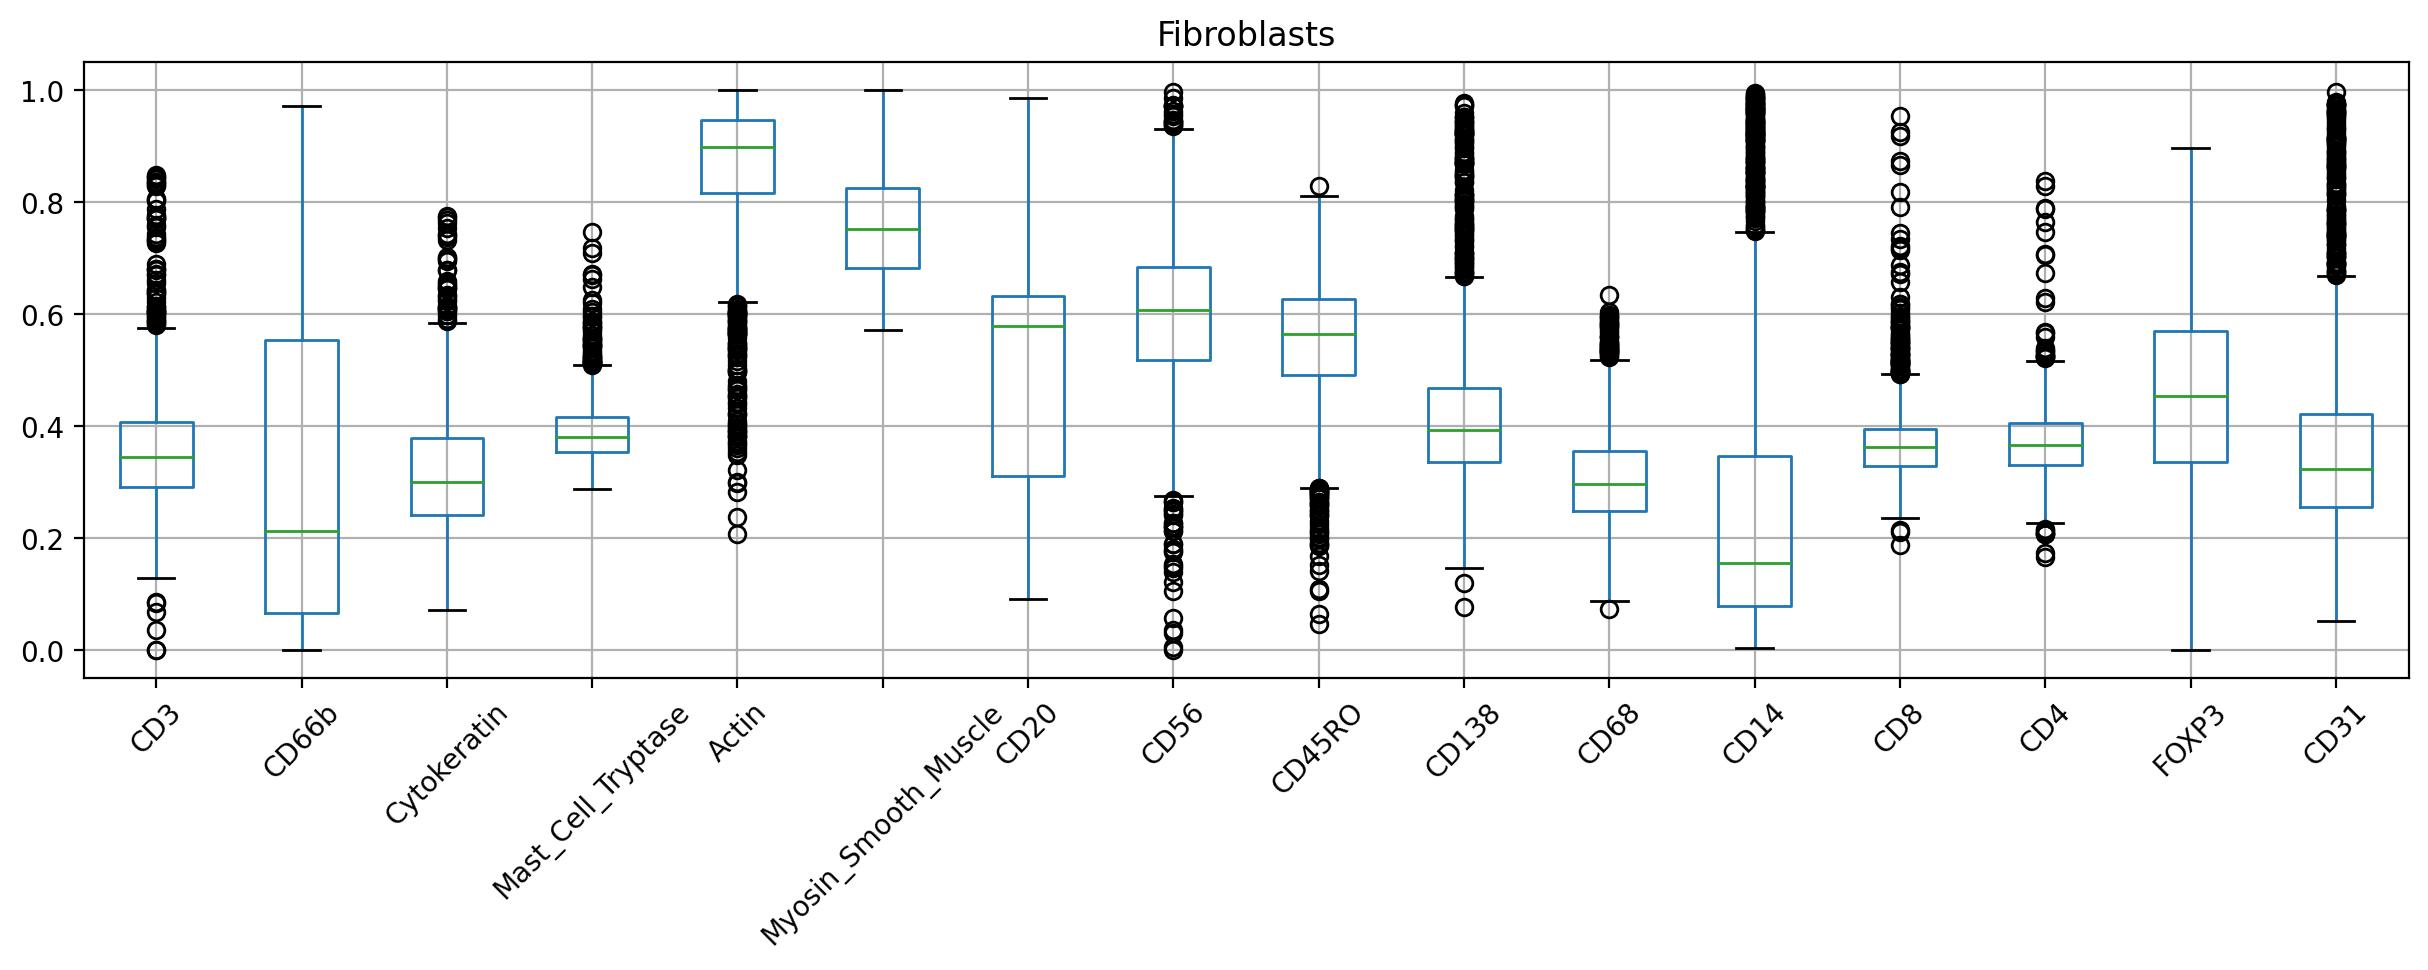

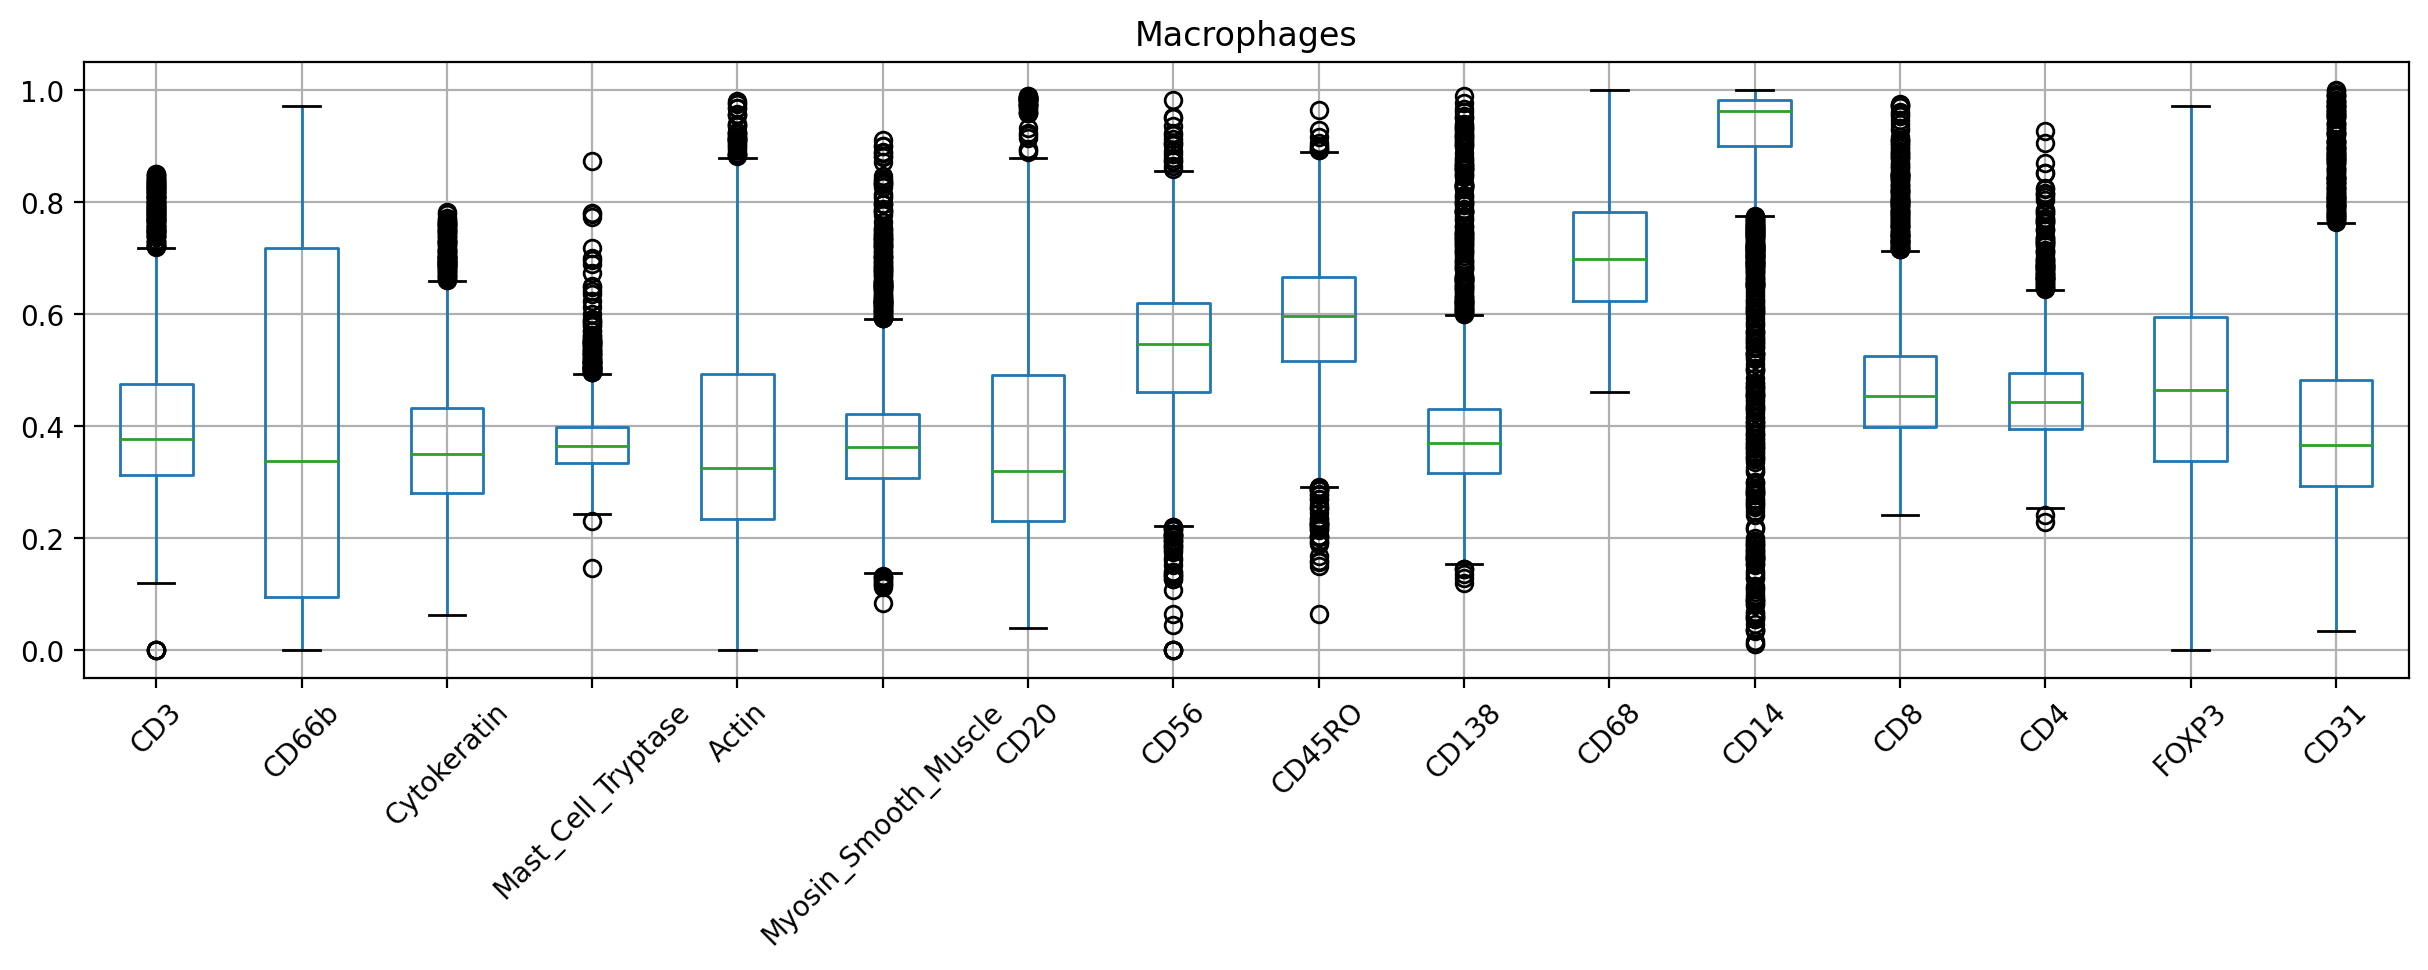

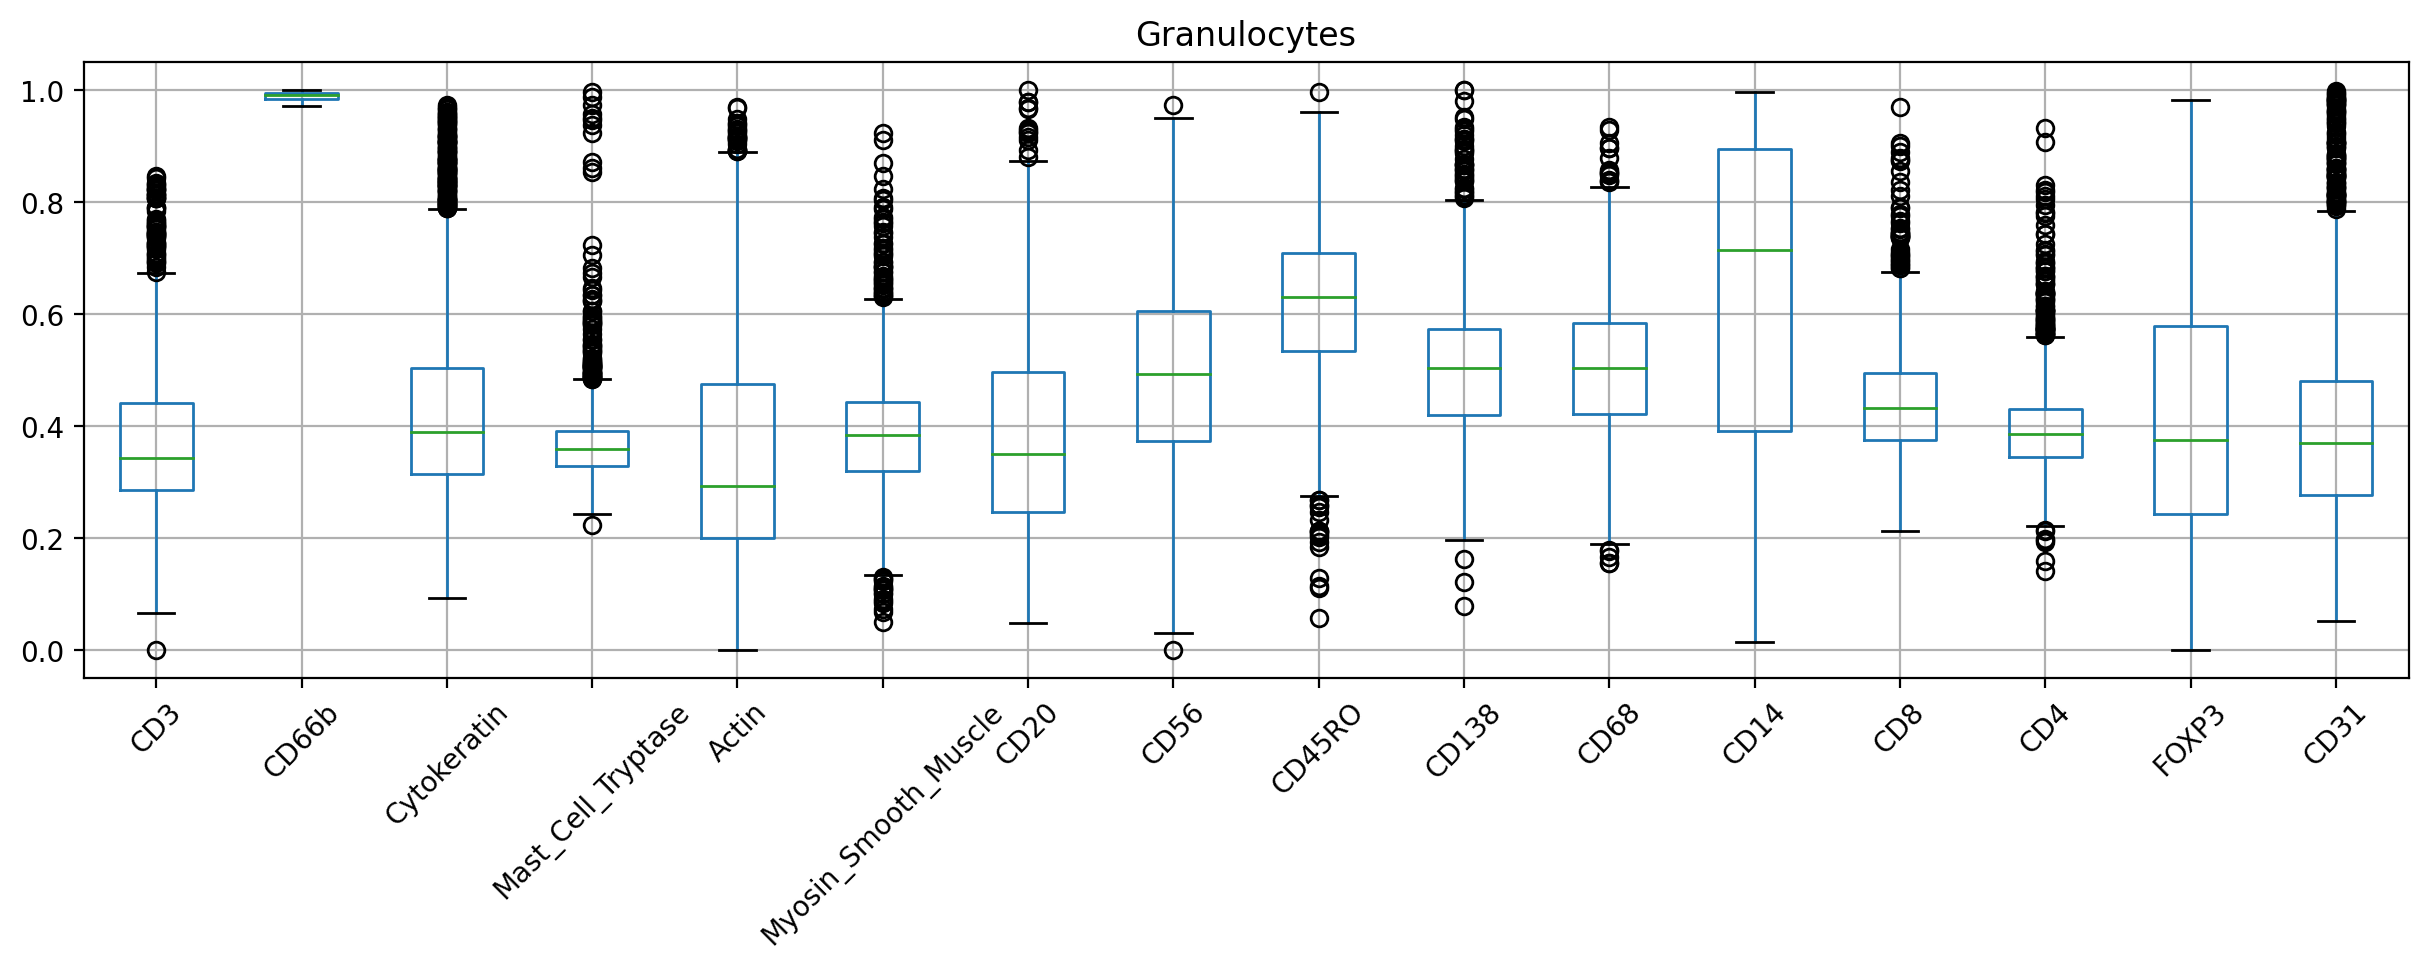

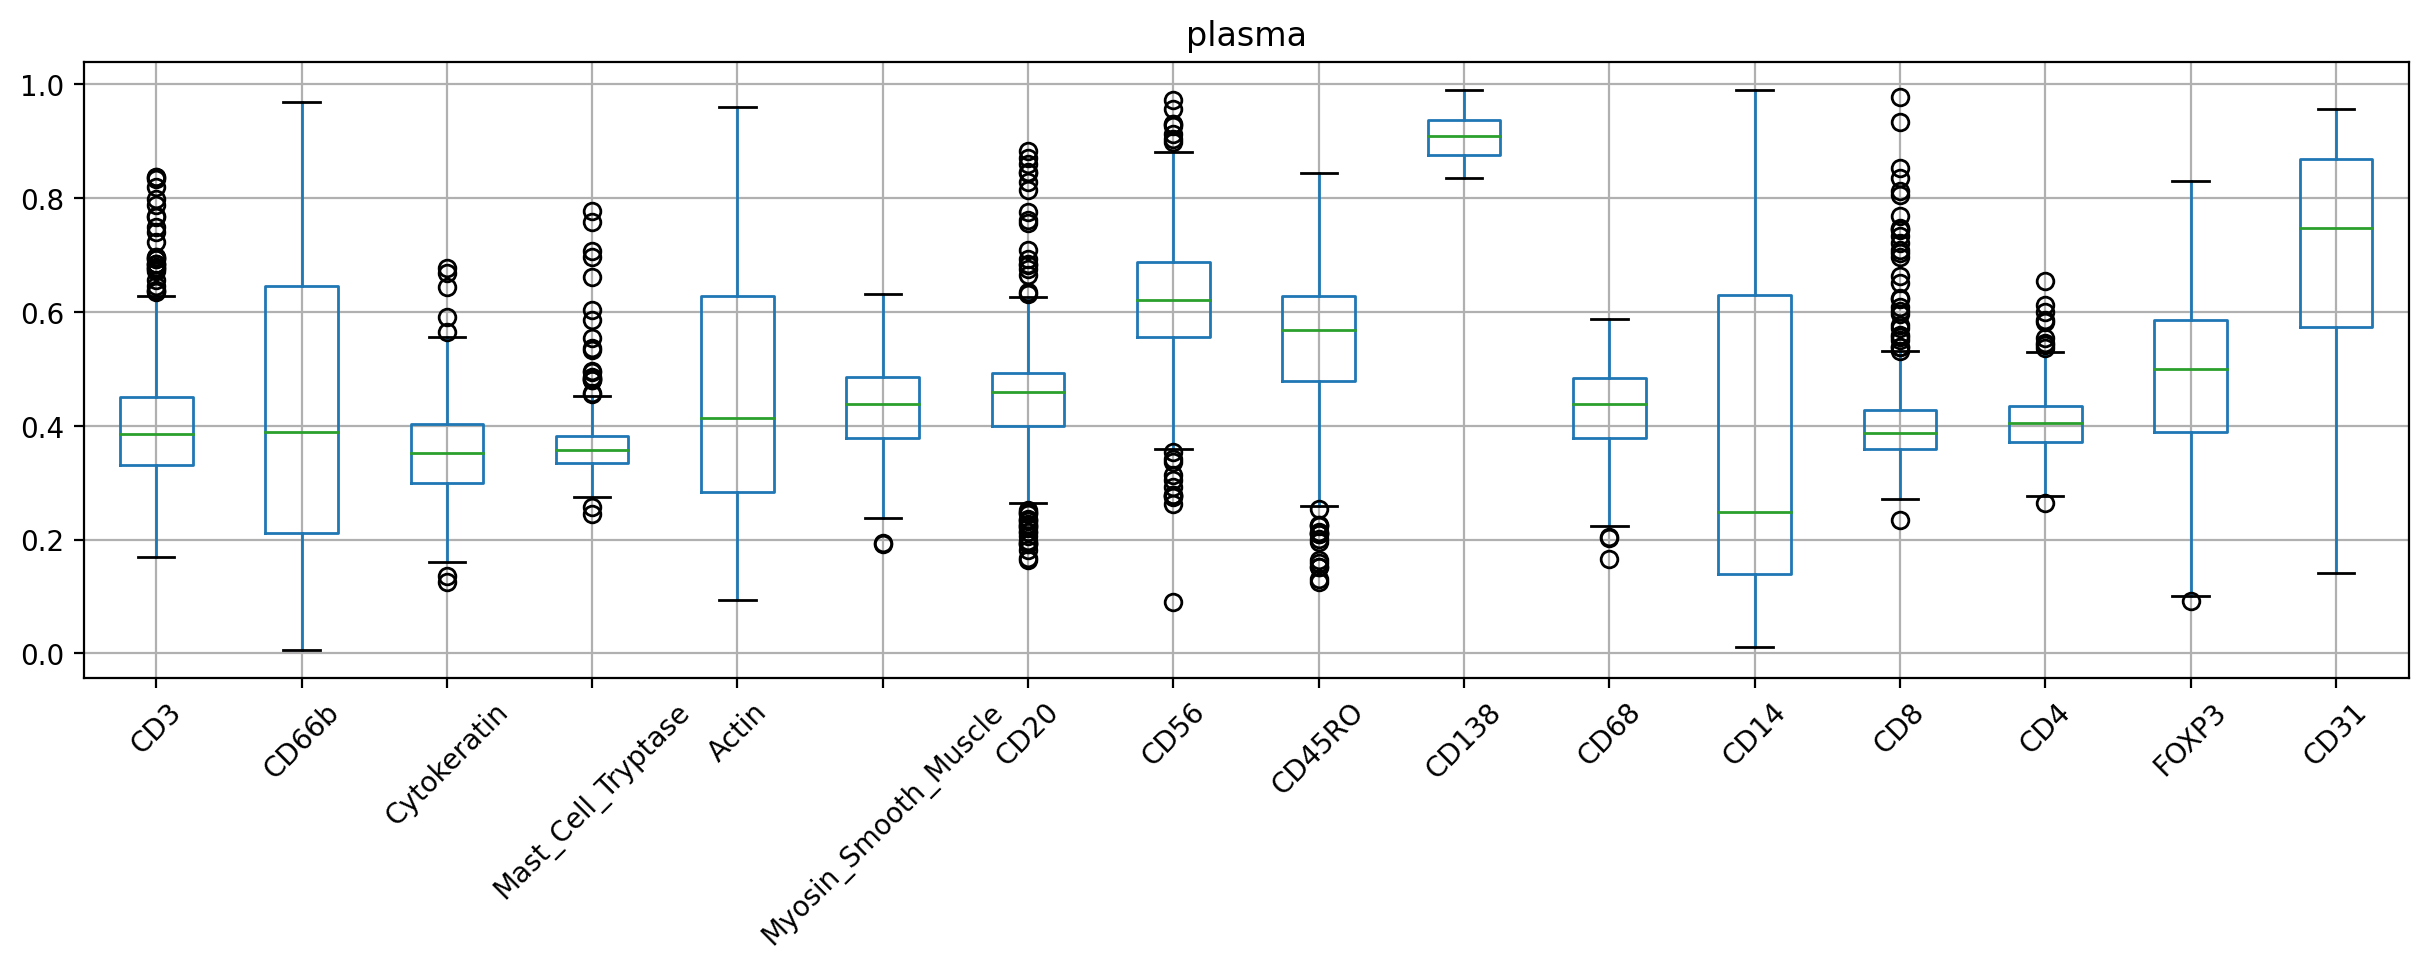

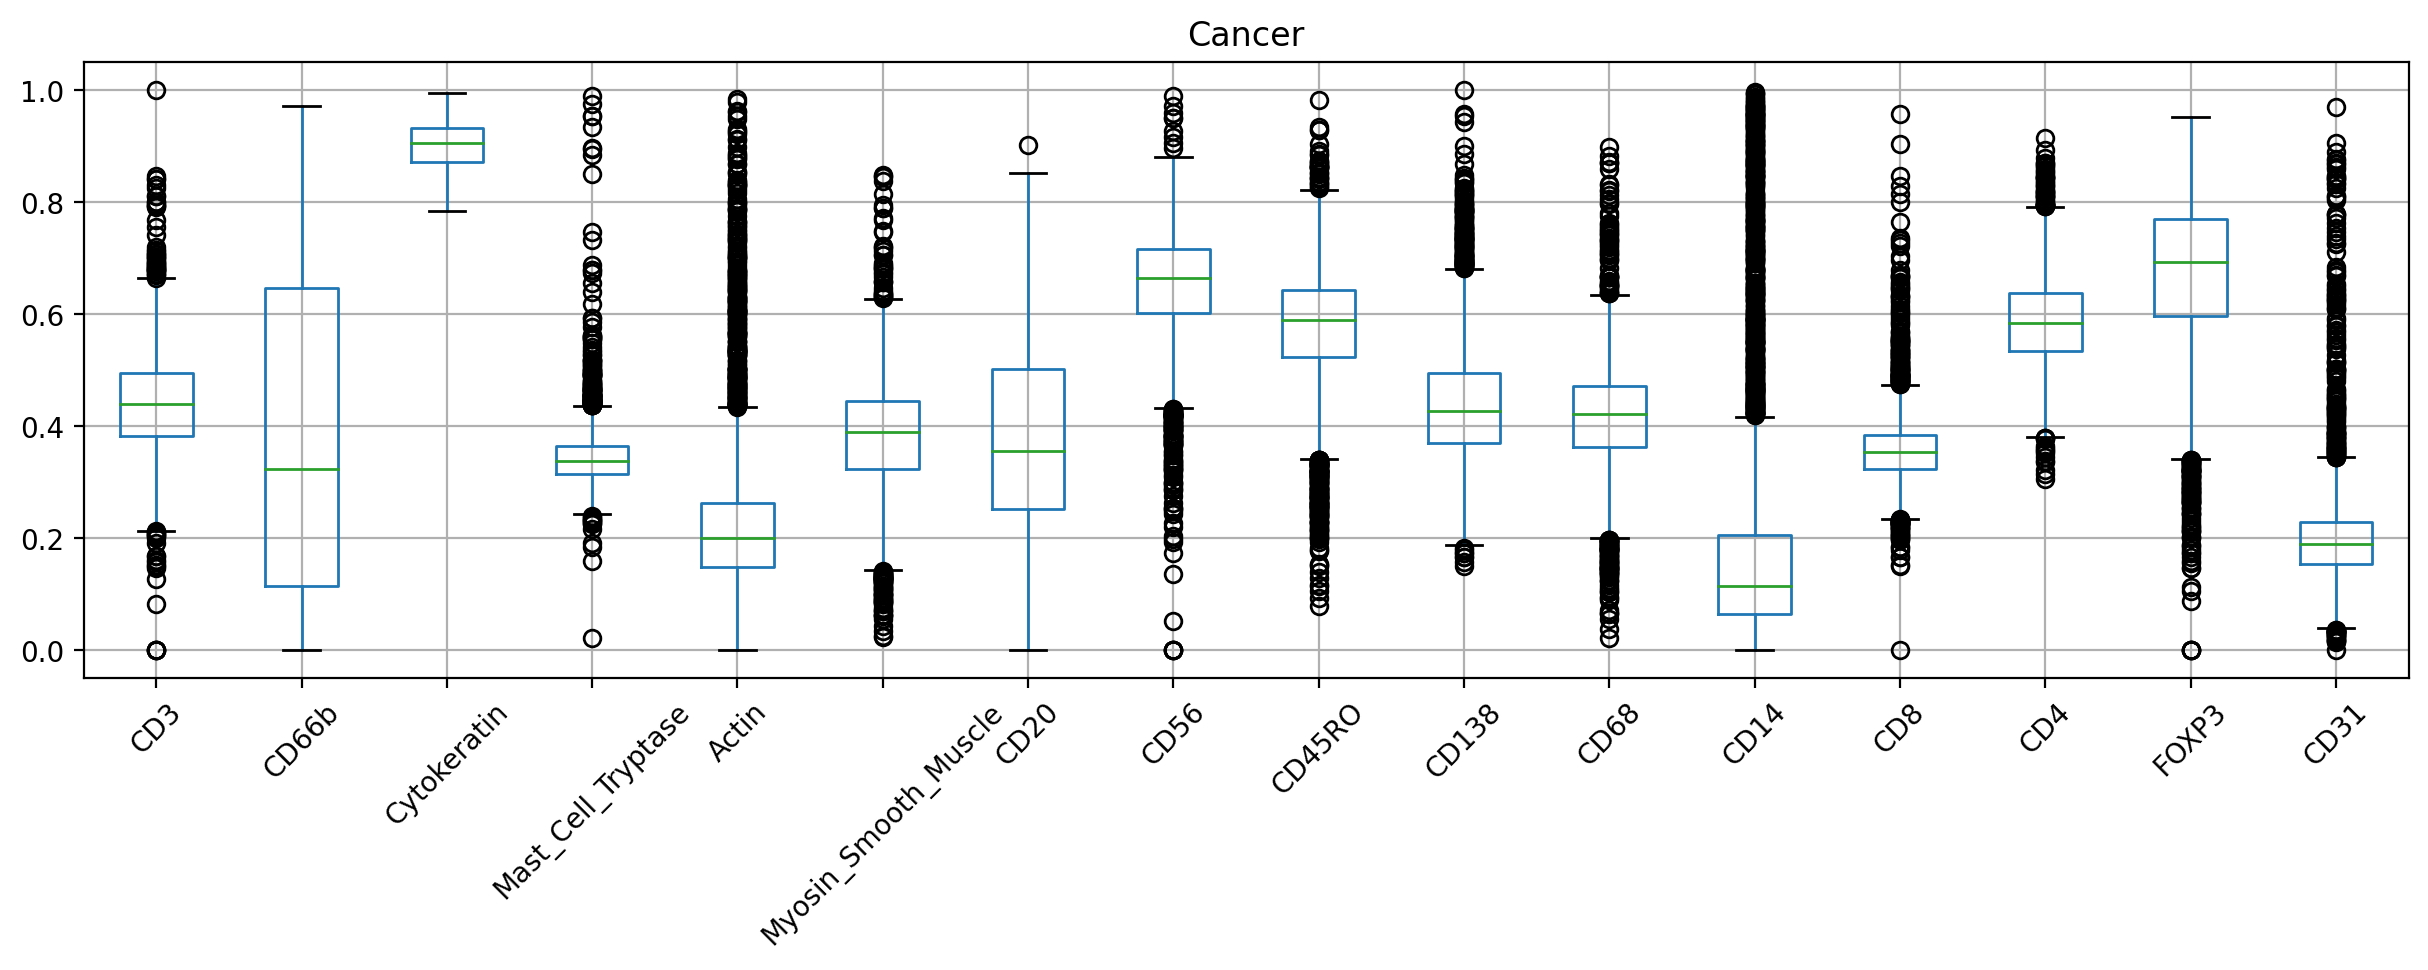

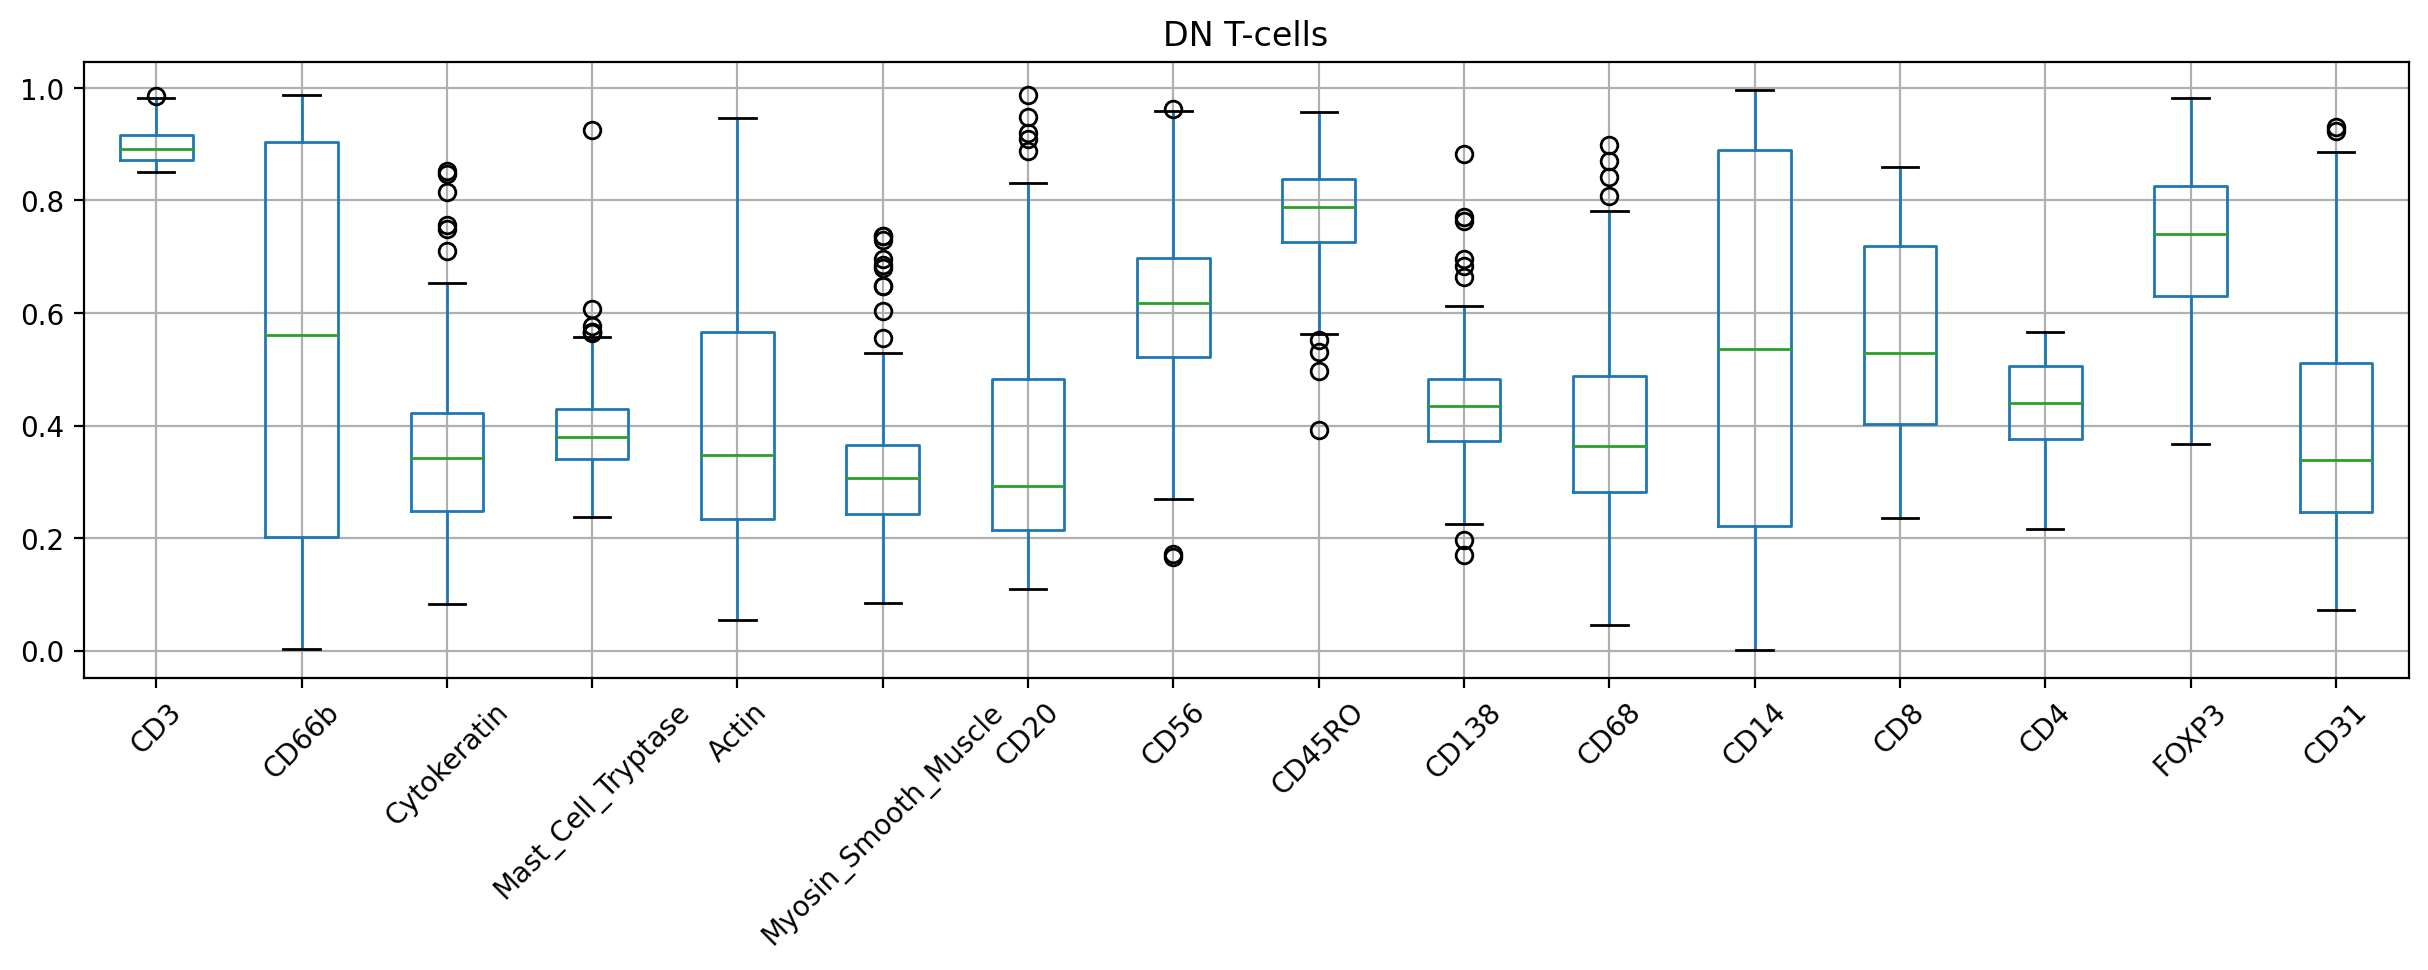

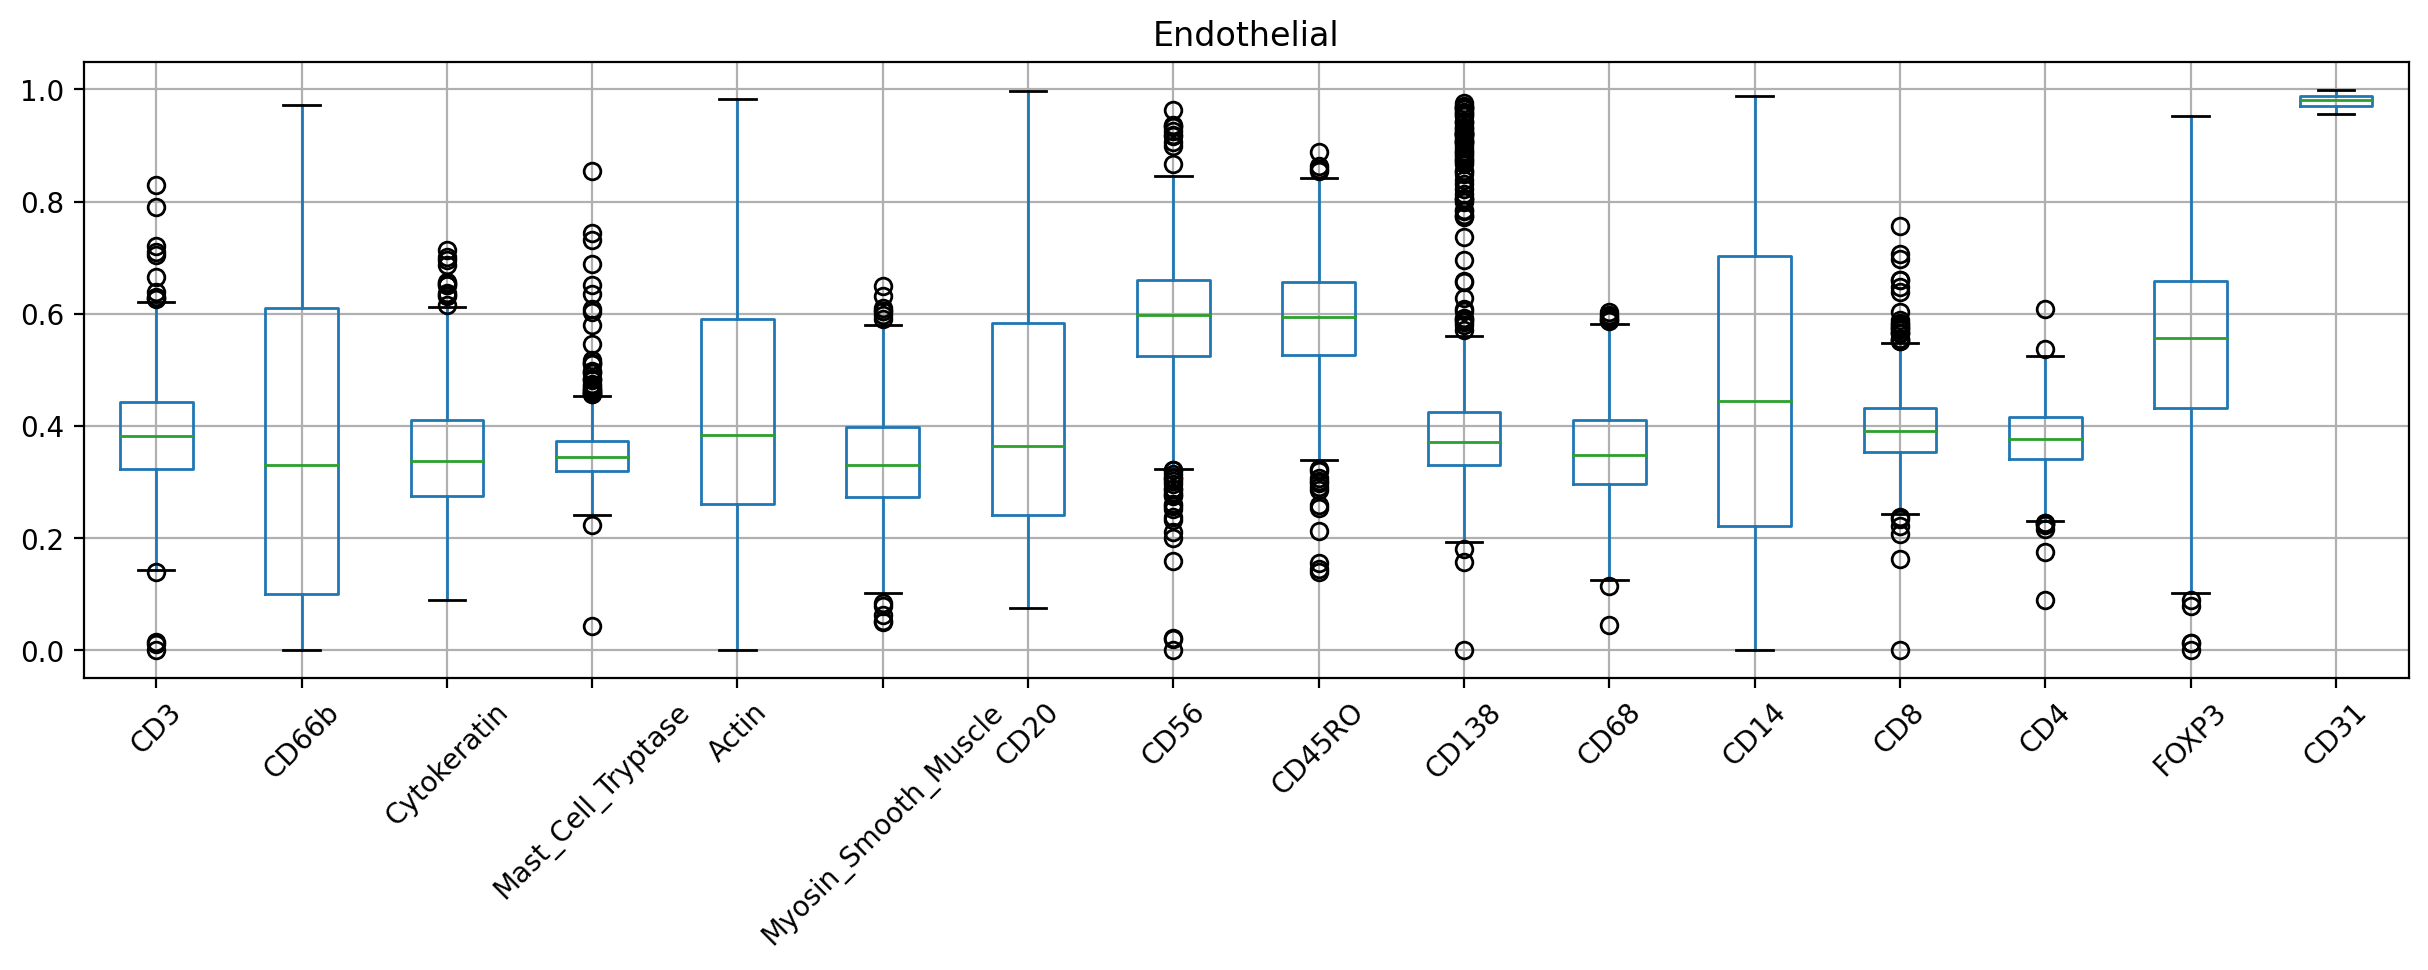

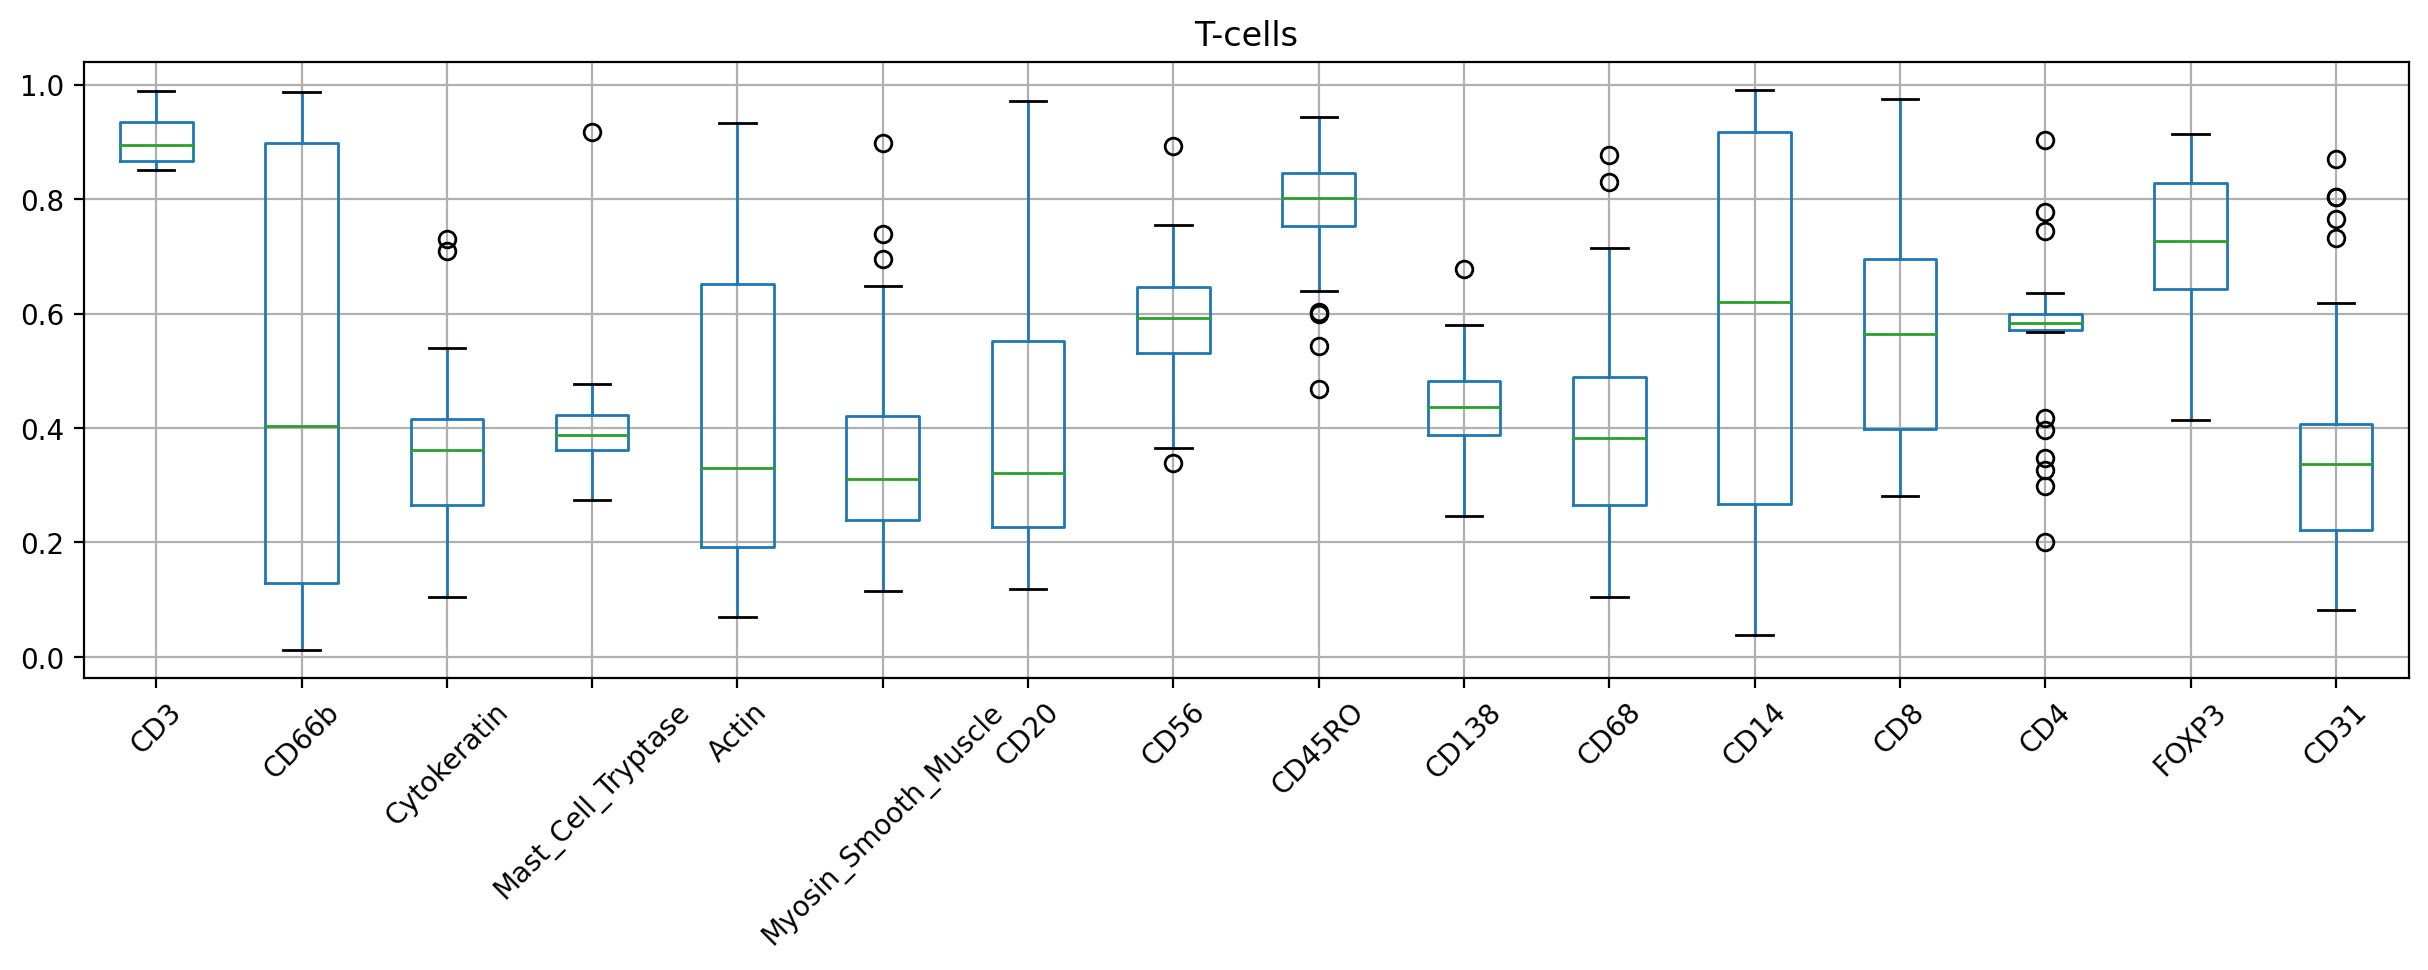

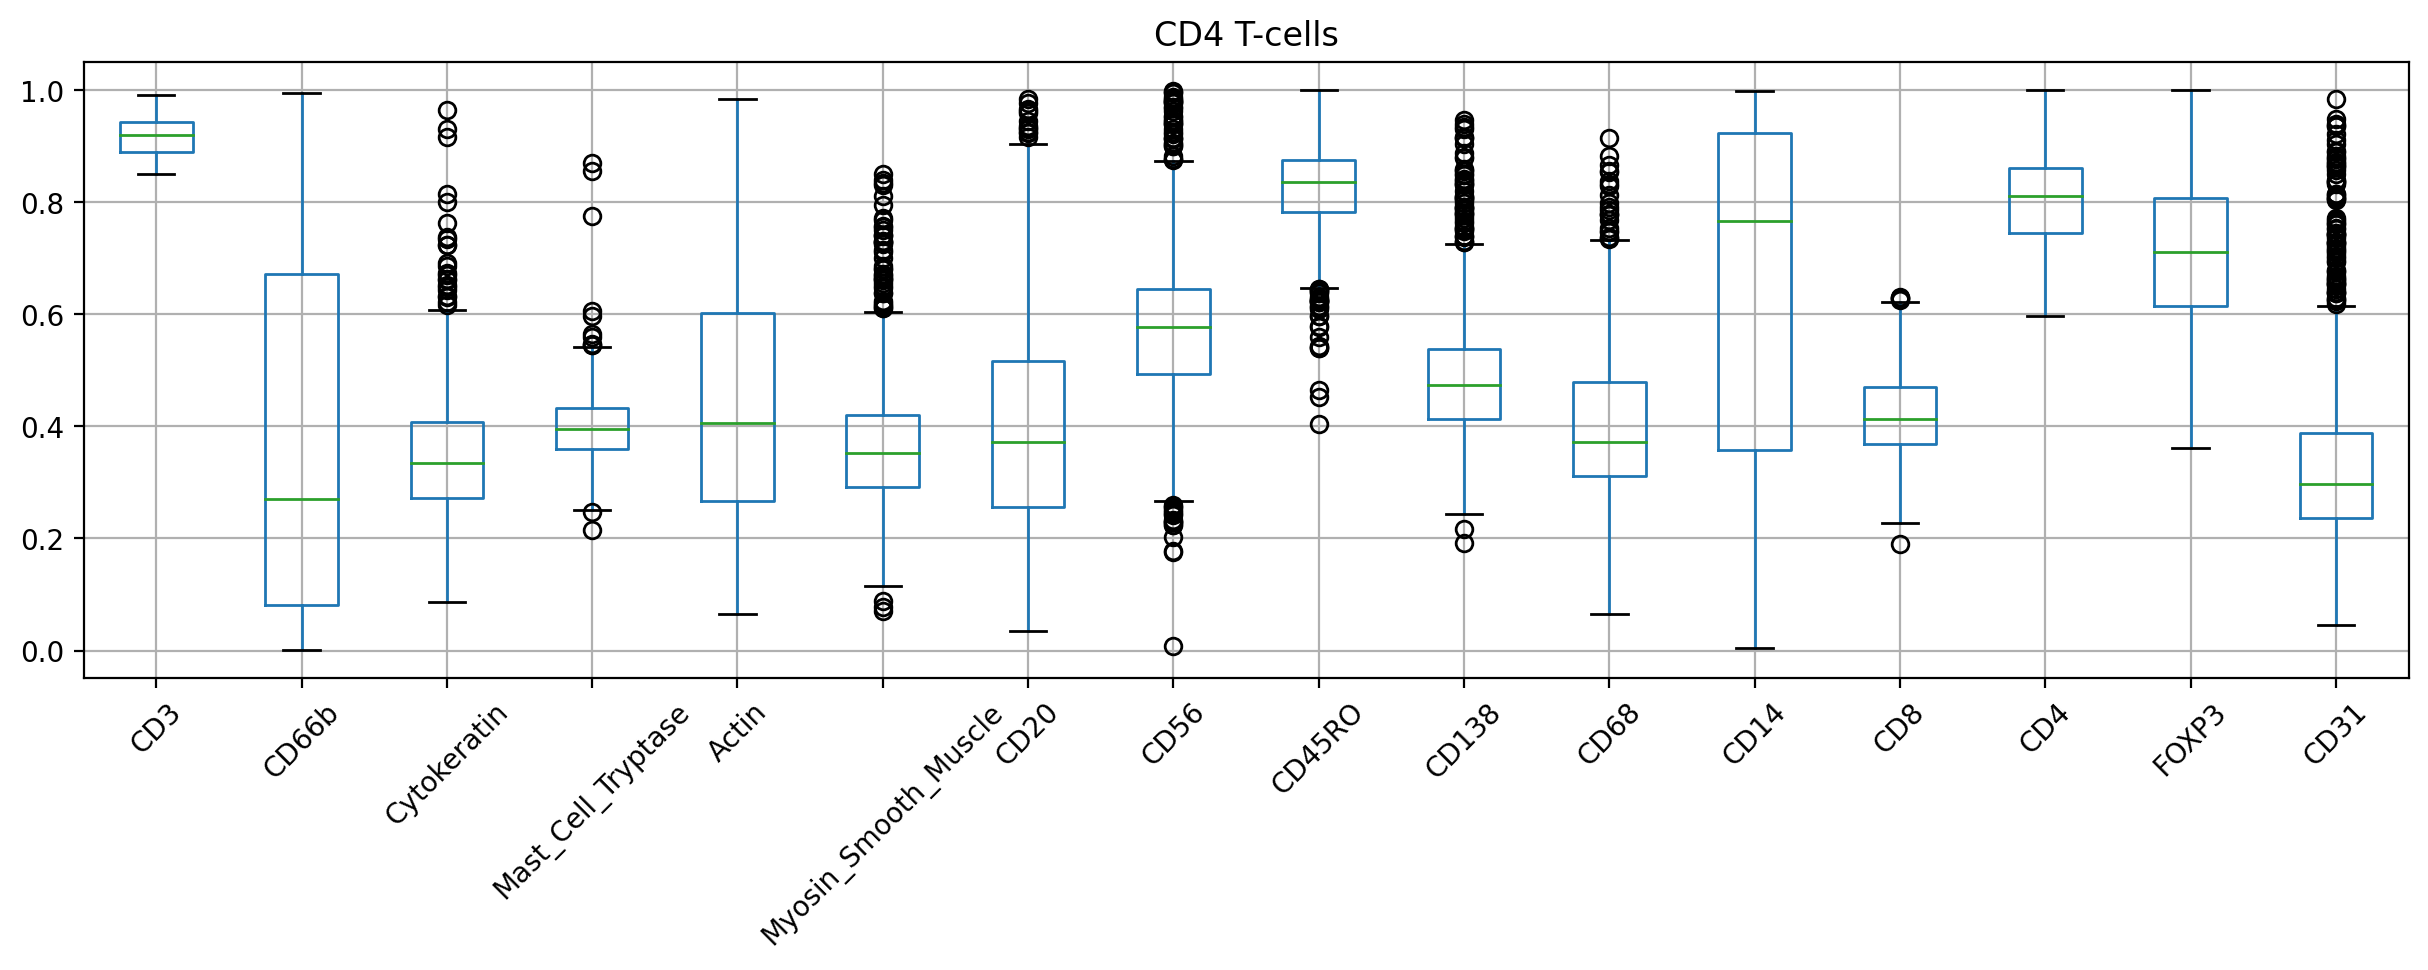

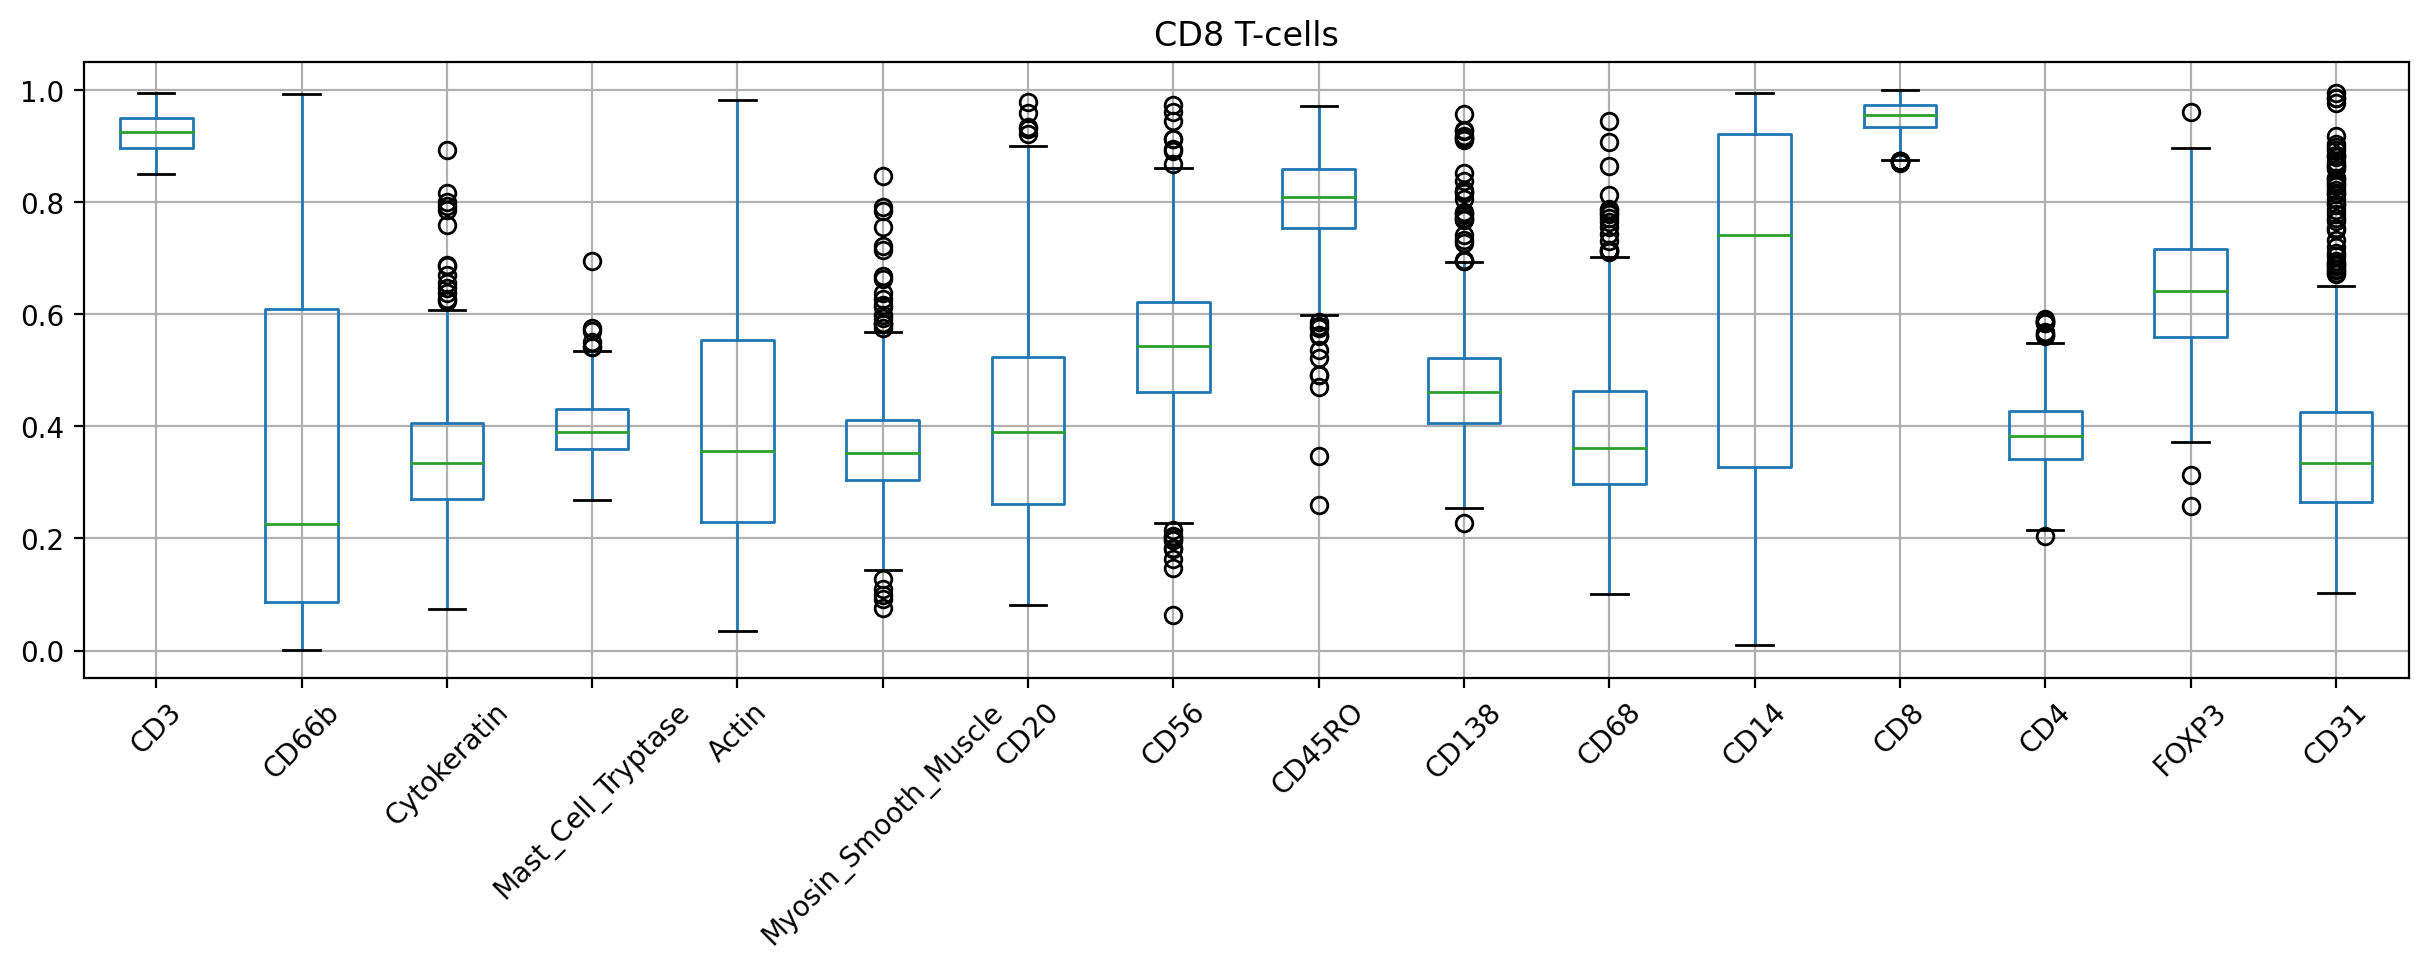

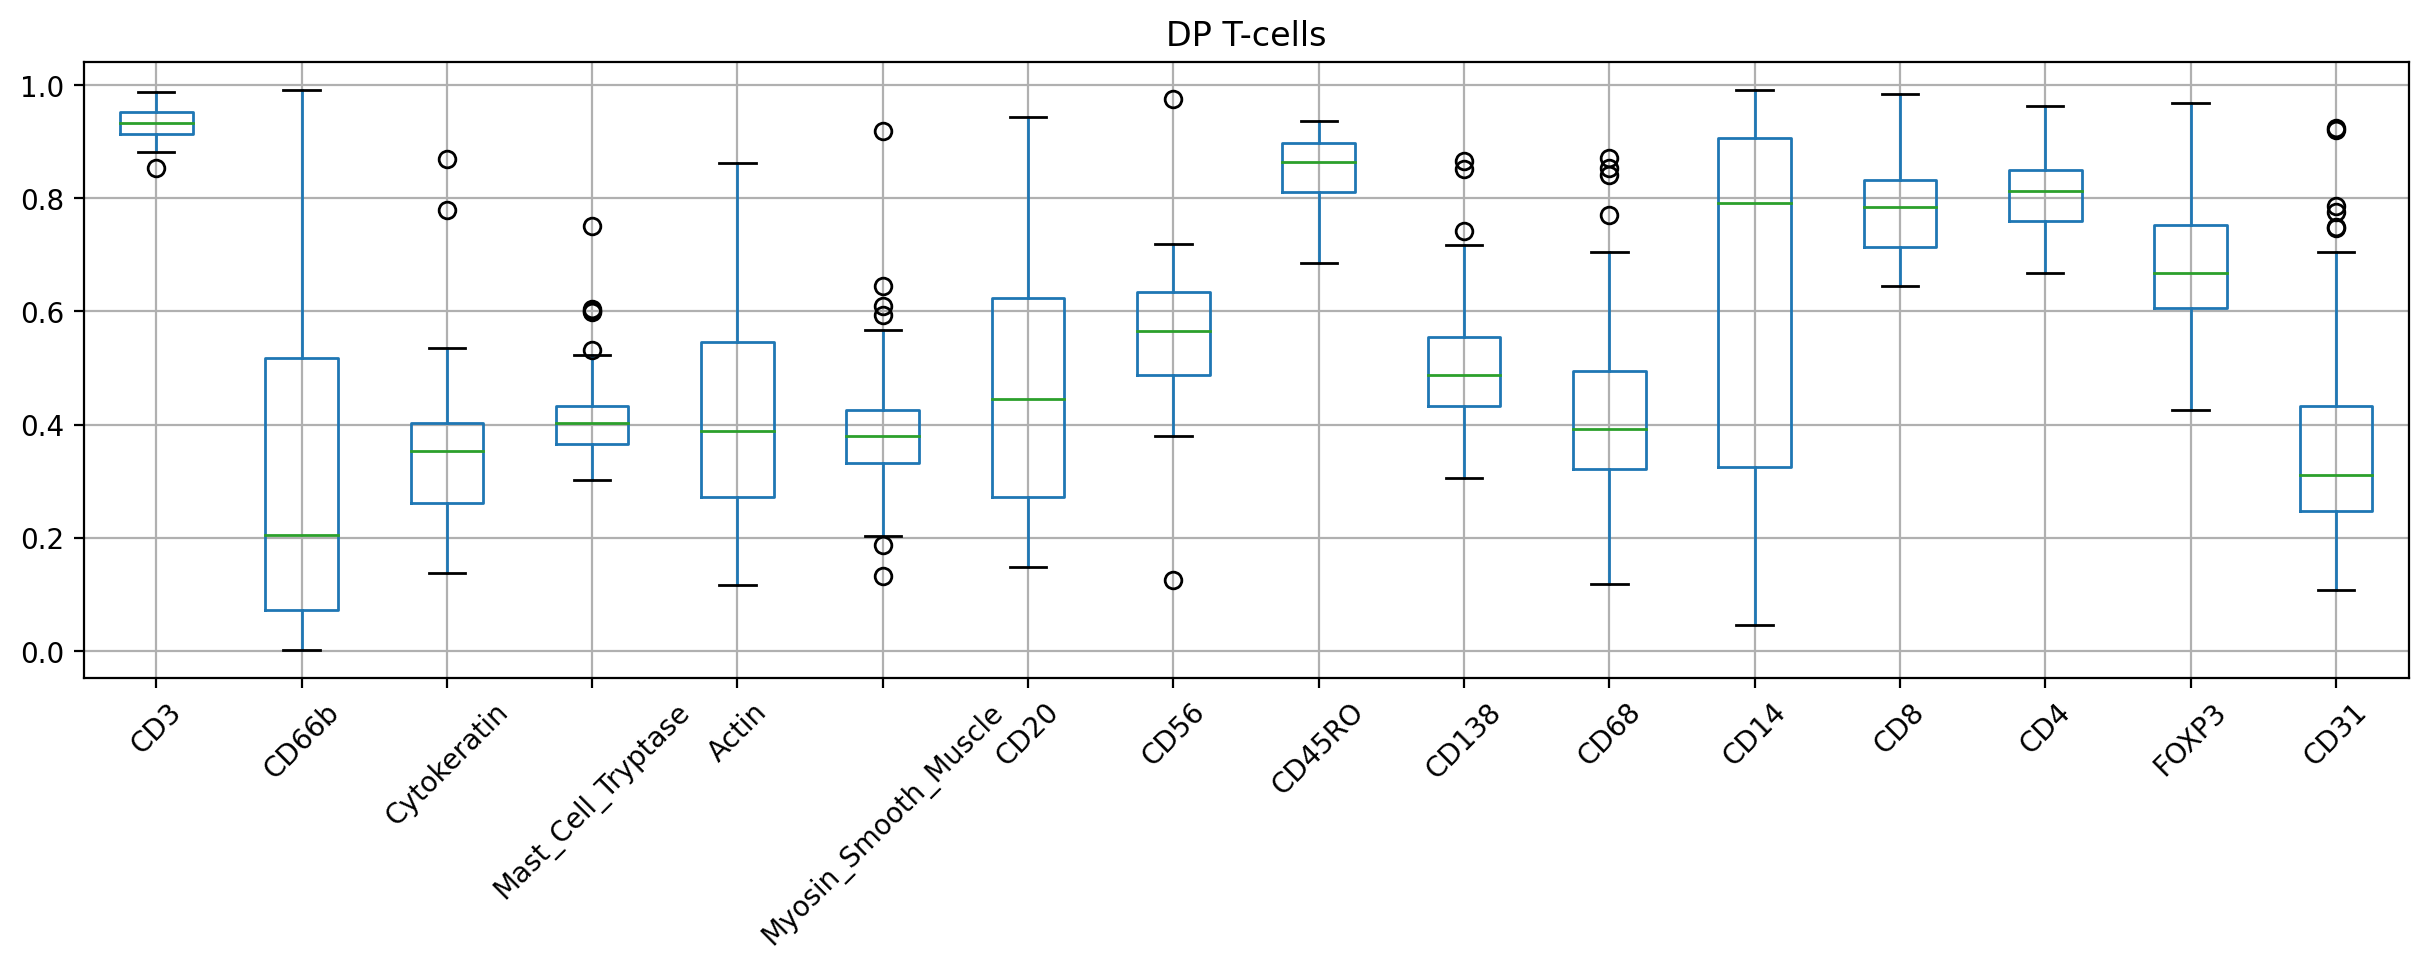

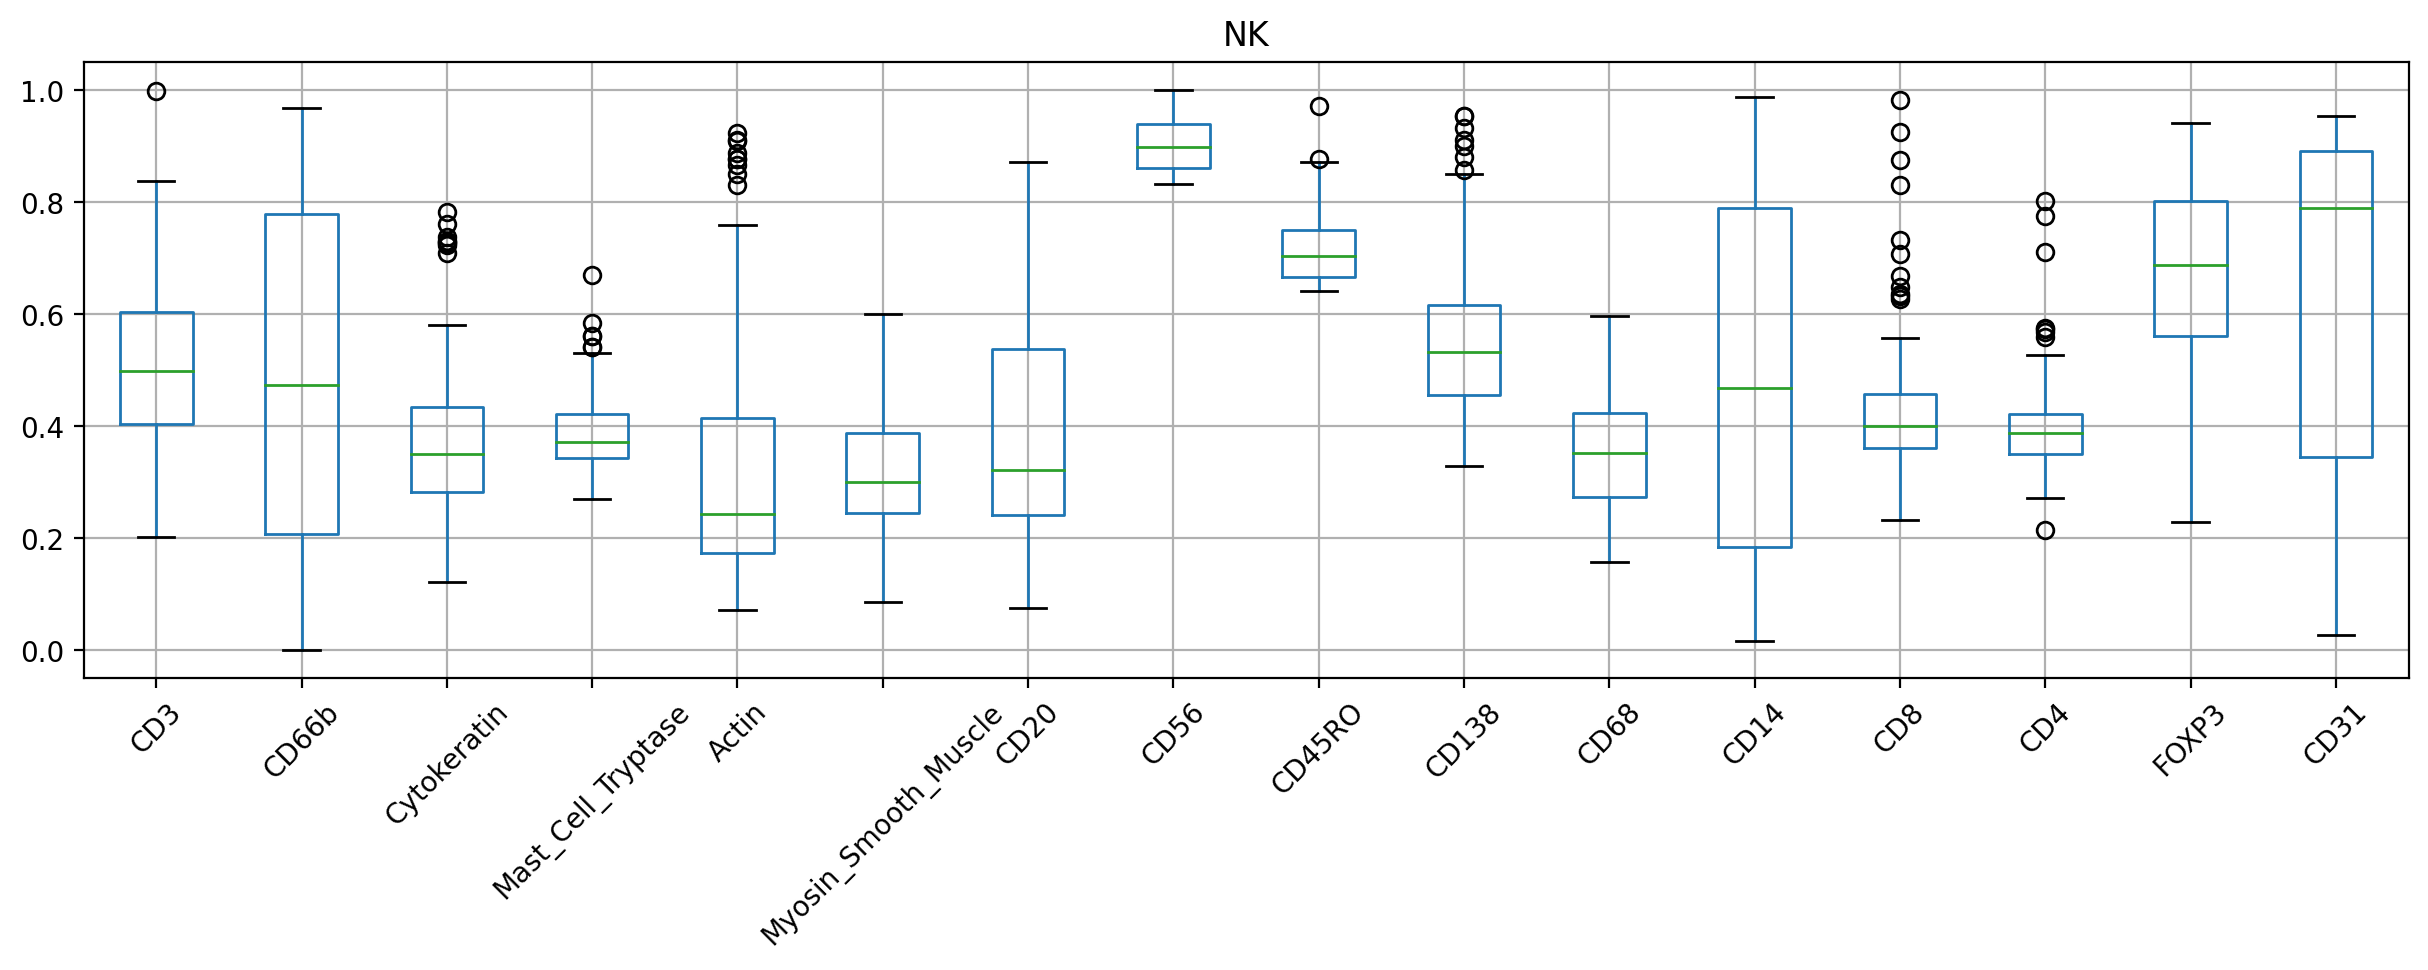

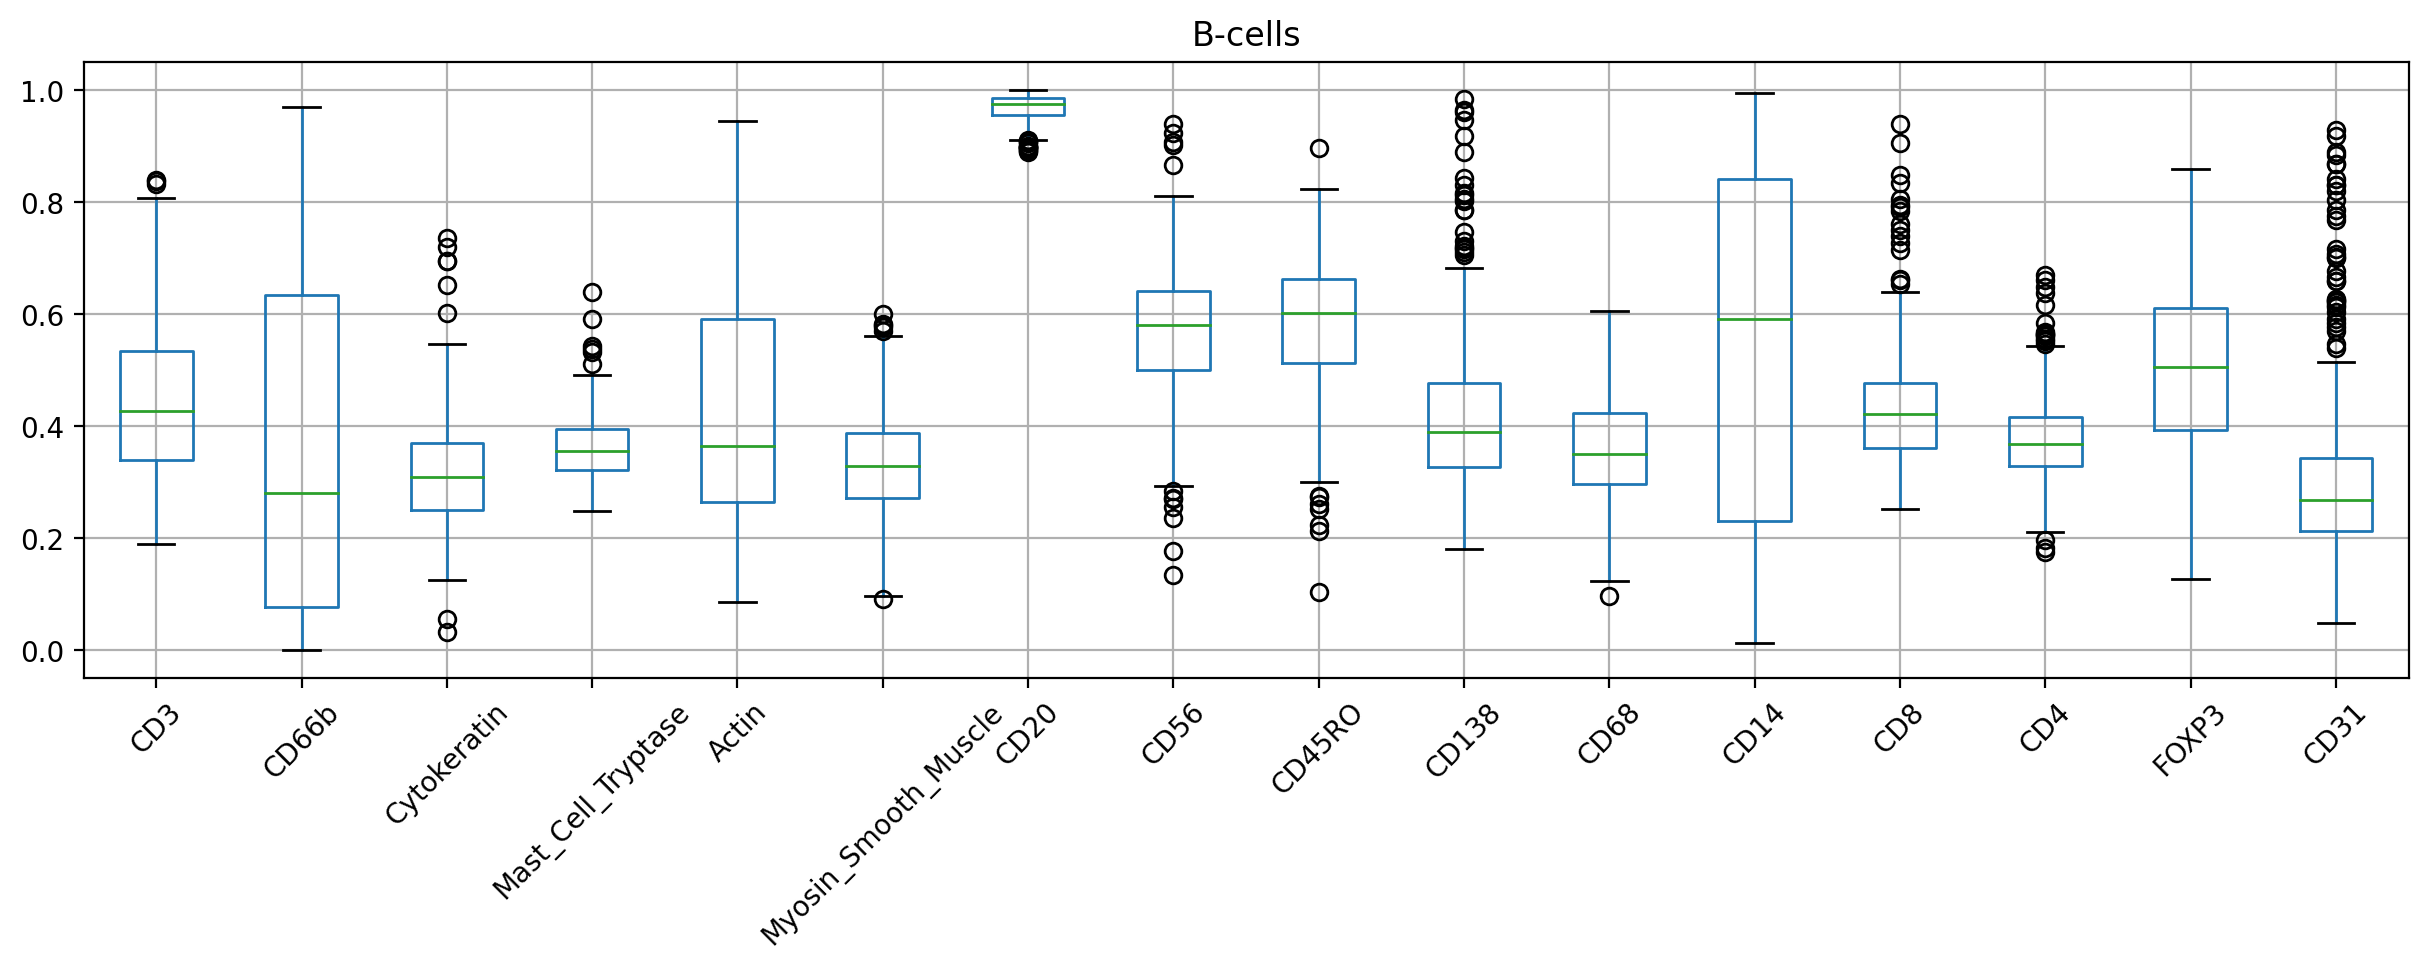

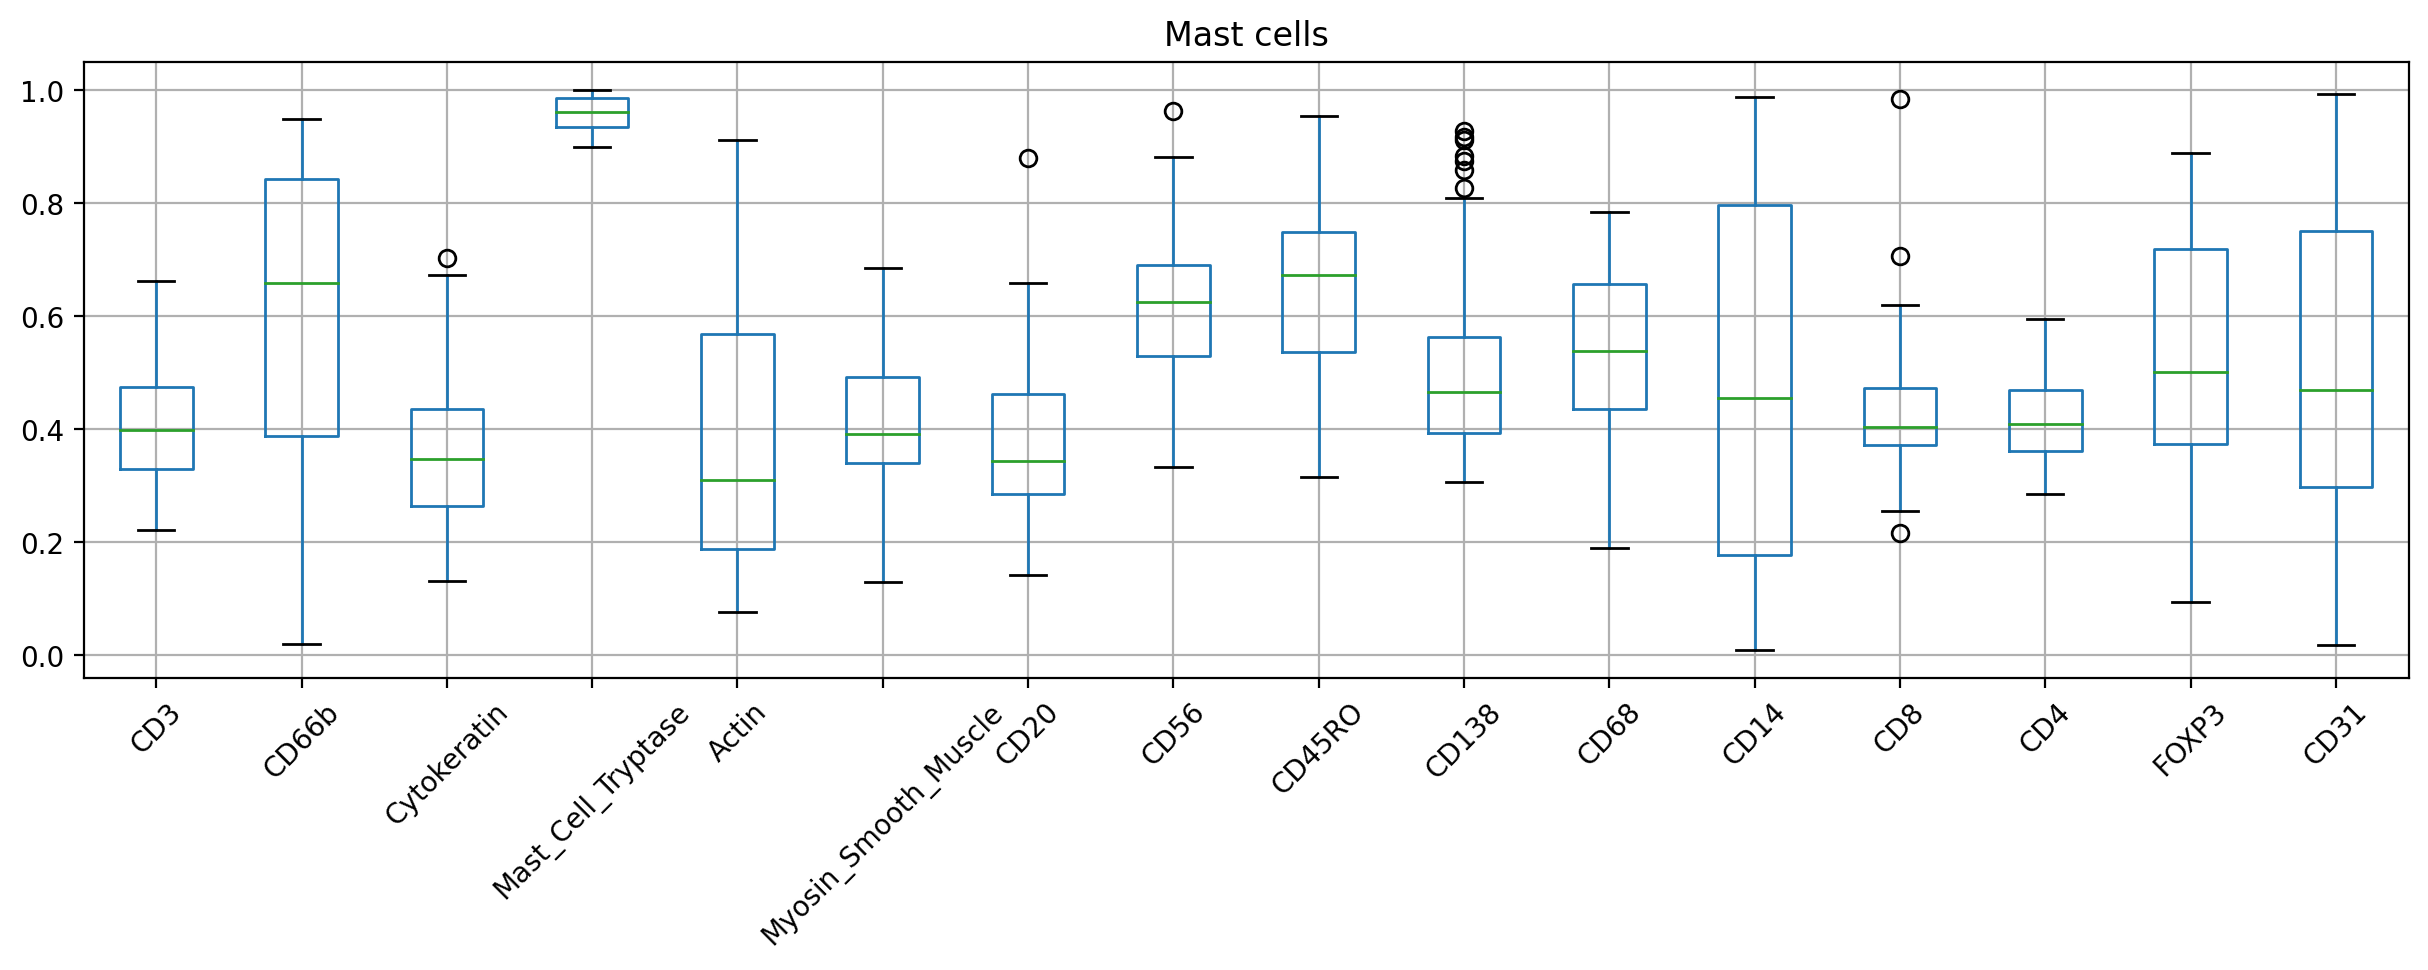

In [19]:
for cell_type,labels in type_label_map.items():
    fig, ax = plt.subplots(1,1, figsize=(15, 4))
    celesta_pmap_filt.loc[celesta_pmap_filt['cell_label'].isin(labels)].boxplot(
        column=markers_list,
        ax=ax,
        rot=45)
    #ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
    plt.title(cell_type)
    plt.savefig(data_dir / 'round_{s}'.format(s=round_suffix)   / 'annotation_plots' / 'boxplot_expressionP_{c}.png'.format(c=cell_type),format='png',bbox_inches="tight")

In [83]:
seg_masks=tifff.imread(seg_masks_path)

In [84]:
for cell_type,labels in type_label_map.items():
    
    canvas=np.zeros(seg_masks.shape,dtype='uint8')
    canvas[np.isin(seg_masks,labels)]=255
    tifff.imwrite( data_dir / 'round_{s}'.format(s=round_suffix) / 'annotation_masks' / '{c}_annotations.tif'.format(c=cell_type), canvas )
    

# Filter celesta results

In [42]:
celesta_dict={'cell_id':img_data.Cell.values,
             'cell_type':celesta_output['Final cell type'].values
             }

In [43]:
df_celesta=pd.DataFrame(celesta_dict)

In [44]:
df_celesta_filt=df_celesta.loc[df_celesta['cell_id'].isin(df_macsiq_filt['cell_id'].values)]

In [45]:
print(df_macsiq_filt.shape)
print(df_celesta_filt.shape)

(15722, 5)
(15722, 2)


In [46]:
num_types={'Unknown':0}
for key,val in lineage_info.items():
    num_types[key]=val[2]

In [47]:
df_celesta_filt.insert(2,'type_no',df_celesta_filt['cell_type'].values)

In [48]:
for cell_type,val in num_types.items():
    df_celesta_filt.loc[df_celesta_filt.cell_type==cell_type,'type_no']=val

In [49]:
df_celesta_filt.to_csv(data_dir / 'round_{s}'.format(s=round_suffix) /'celesta_level{r}.csv'.format(r=round_suffix),index=False)

# 2. Estimate thresholds for celesta

In [20]:
celesta_pmap=pd.read_csv(data_dir / 'celesta_pmap.csv')
celesta_pmap.rename(columns={'Unnamed: 0':'cell_label'},inplace=True)

## 2.1 Otsu

In [24]:
thr_otsu={}
for marker in celesta_pmap.columns[1::]:
    
    #thr_otsu[marker]=[f'{threshold_multiotsu(celesta_pmap[marker].values,classes=3)[0]:.2f}']
    thr_otsu[marker]=threshold_multiotsu(celesta_pmap[marker].values,classes=3)
    
thr_otsu_df=pd.DataFrame(thr_otsu)
#thr_otsu_df.to_csv(data_dir / 'round_{s}'.format(s=round_suffix)   / 'celesta_output' / 'otsu' / 'thr_input.csv',index=False)

#thr_otsu_df
thr_otsu

{'CD3': array([0.40039062, 0.67773438]),
 'CD66b': array([0.30273438, 0.68554688]),
 'Cytokeratin': array([0.35742188, 0.66210938]),
 'Mast_Cell_Tryptase': array([0.36914062, 0.59179688]),
 'Actin': array([0.34570312, 0.64648438]),
 'Myosin_Smooth_Muscle': array([0.33789062, 0.56835938]),
 'CD20': array([0.34179688, 0.55664062]),
 'CD56': array([0.45117188, 0.63085938]),
 'CD45RO': array([0.49023438, 0.67382812]),
 'CD138': array([0.41992188, 0.65039062]),
 'CD68': array([0.36132812, 0.57226562]),
 'CD14': array([0.30273438, 0.68554688]),
 'CD8': array([0.42382812, 0.67773438]),
 'CD4': array([0.43554688, 0.61914062]),
 'FOXP3': array([0.39648438, 0.63085938]),
 'CD31': array([0.32226562, 0.64257812])}

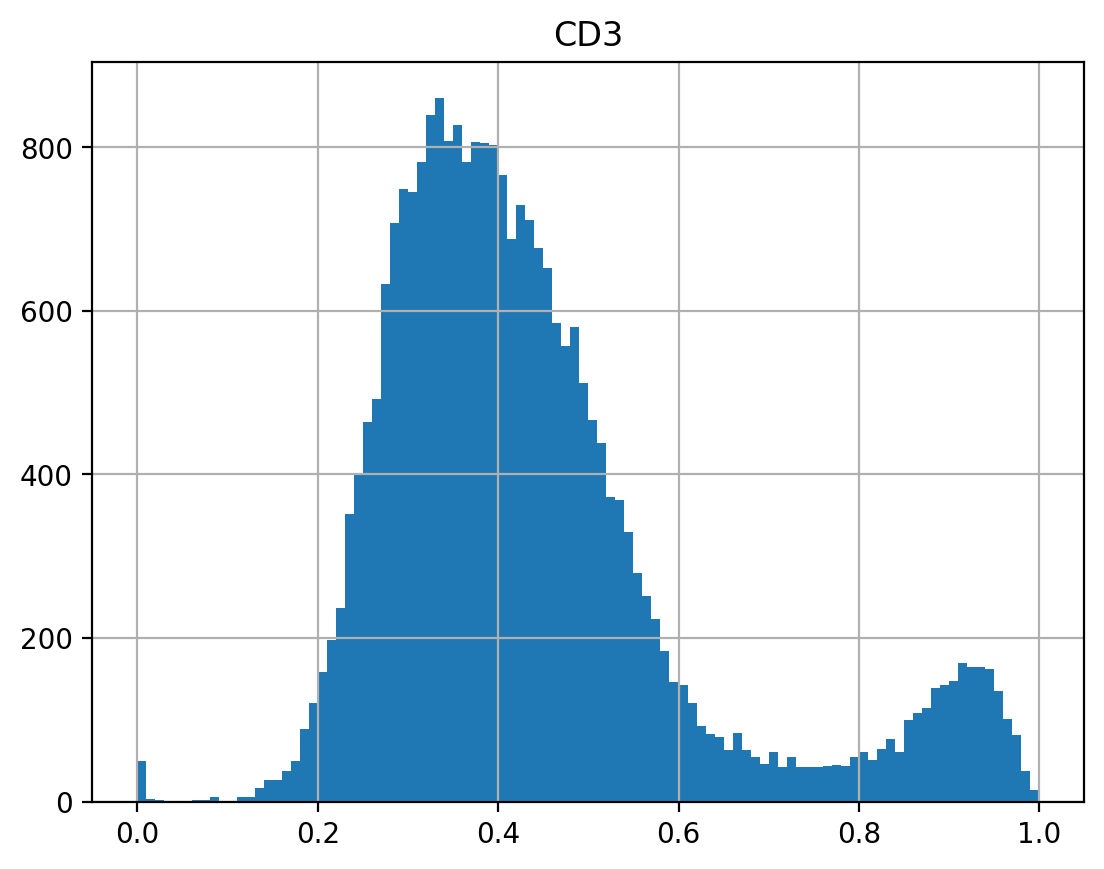

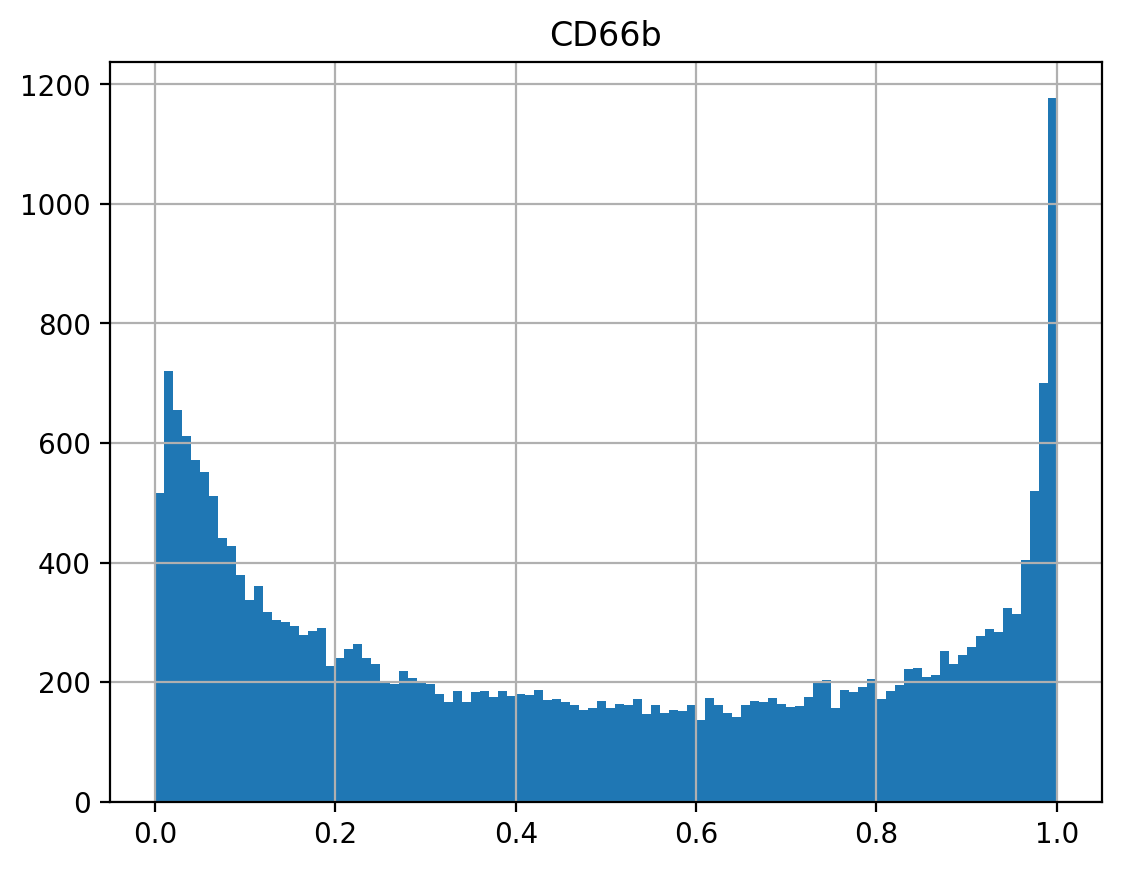

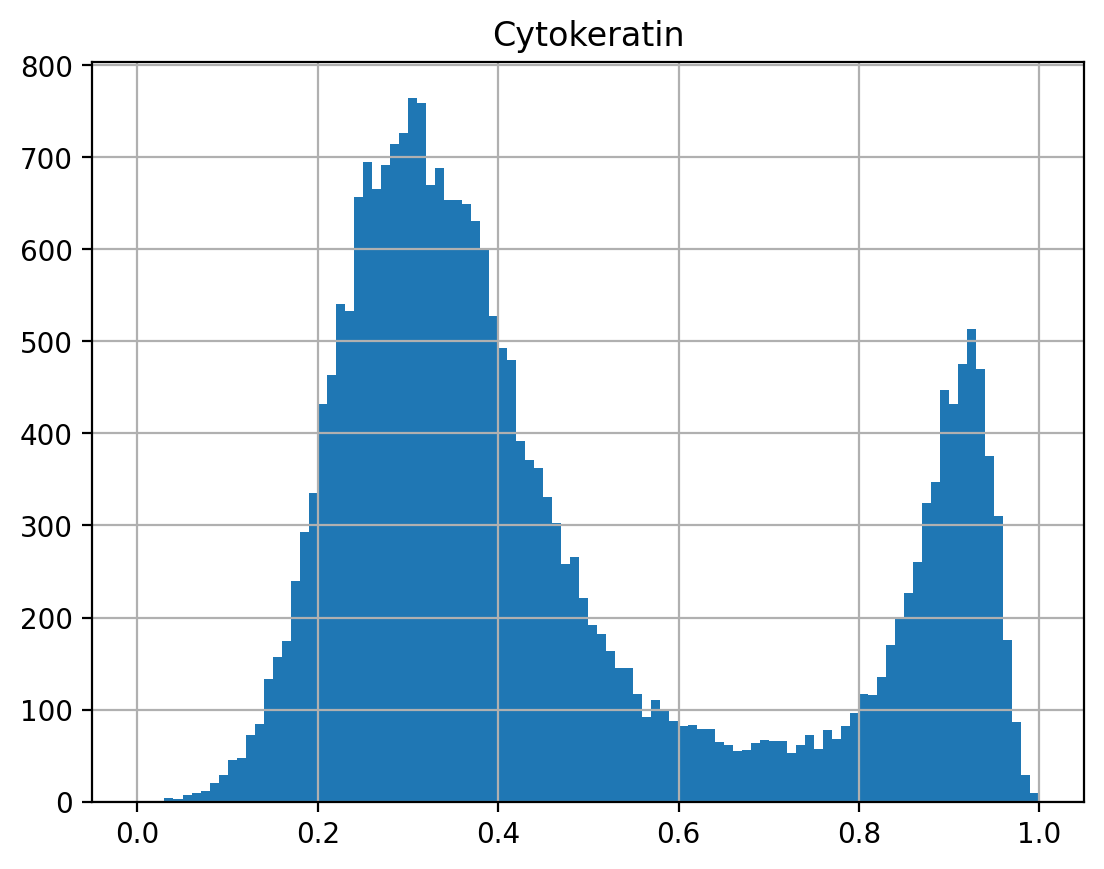

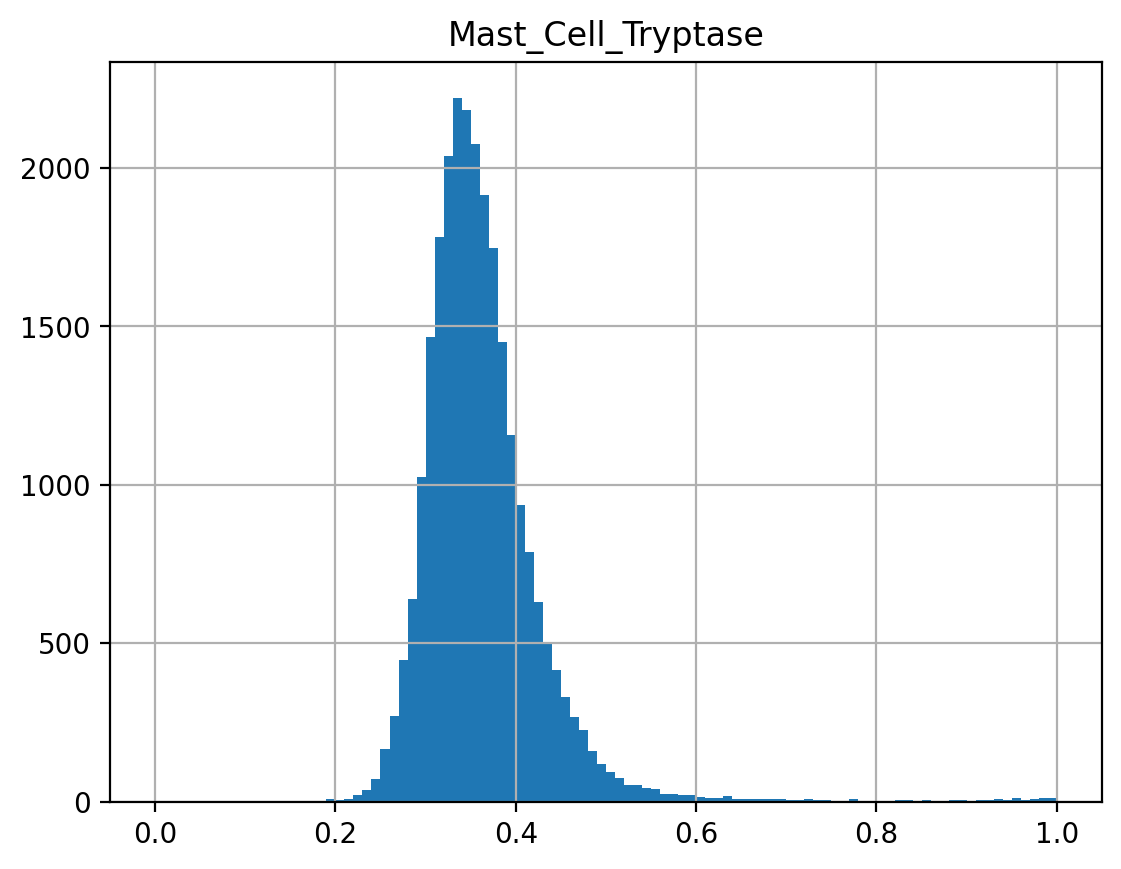

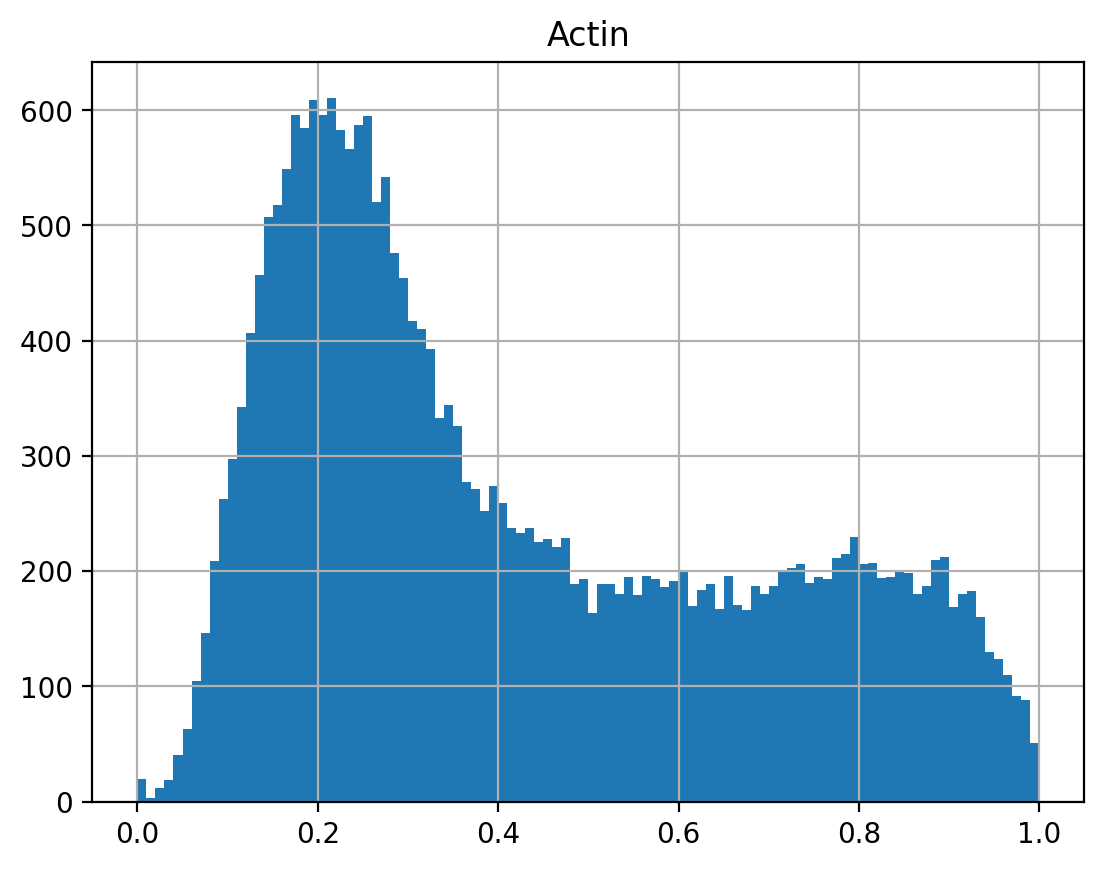

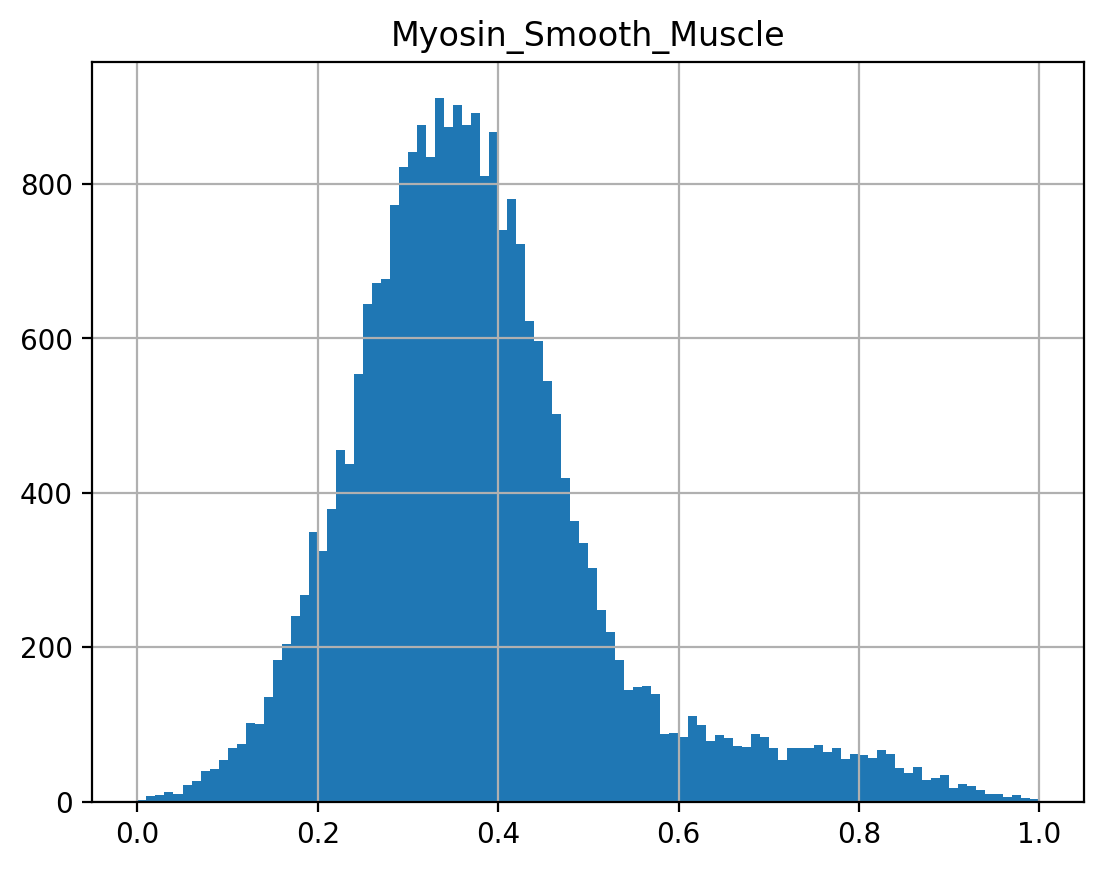

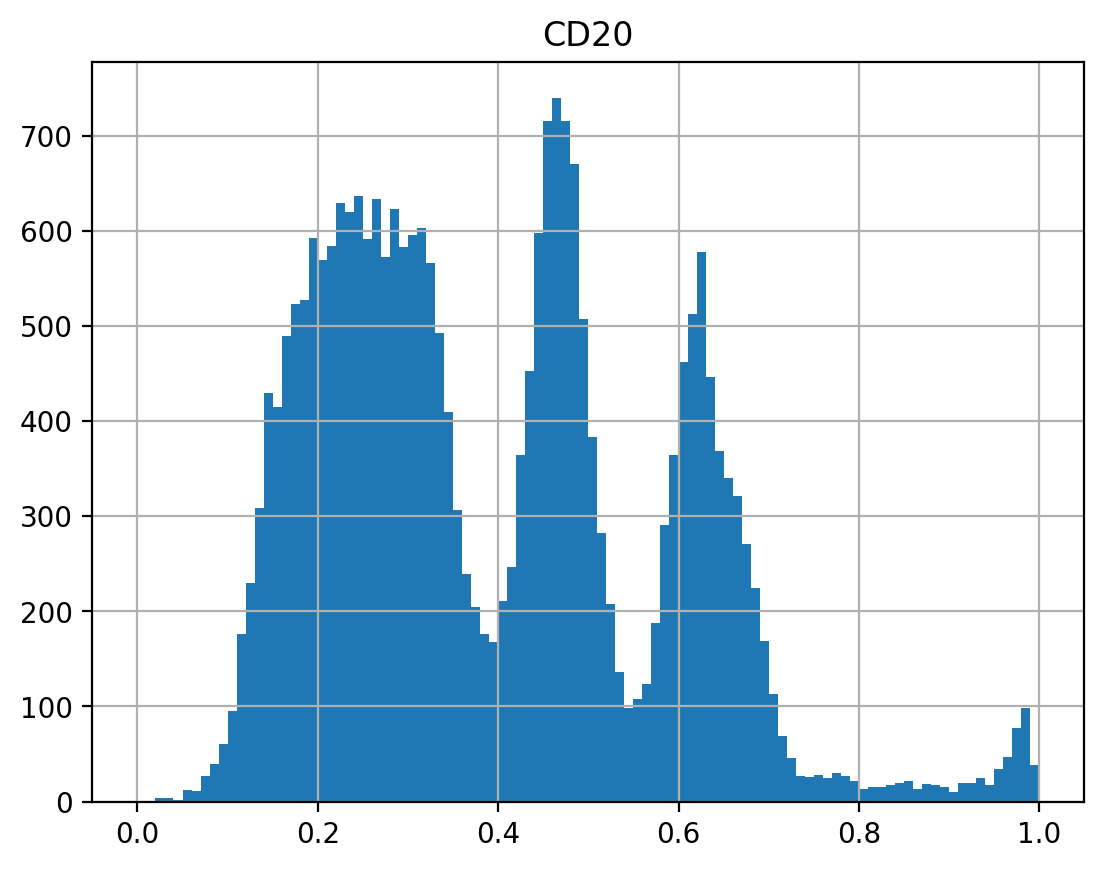

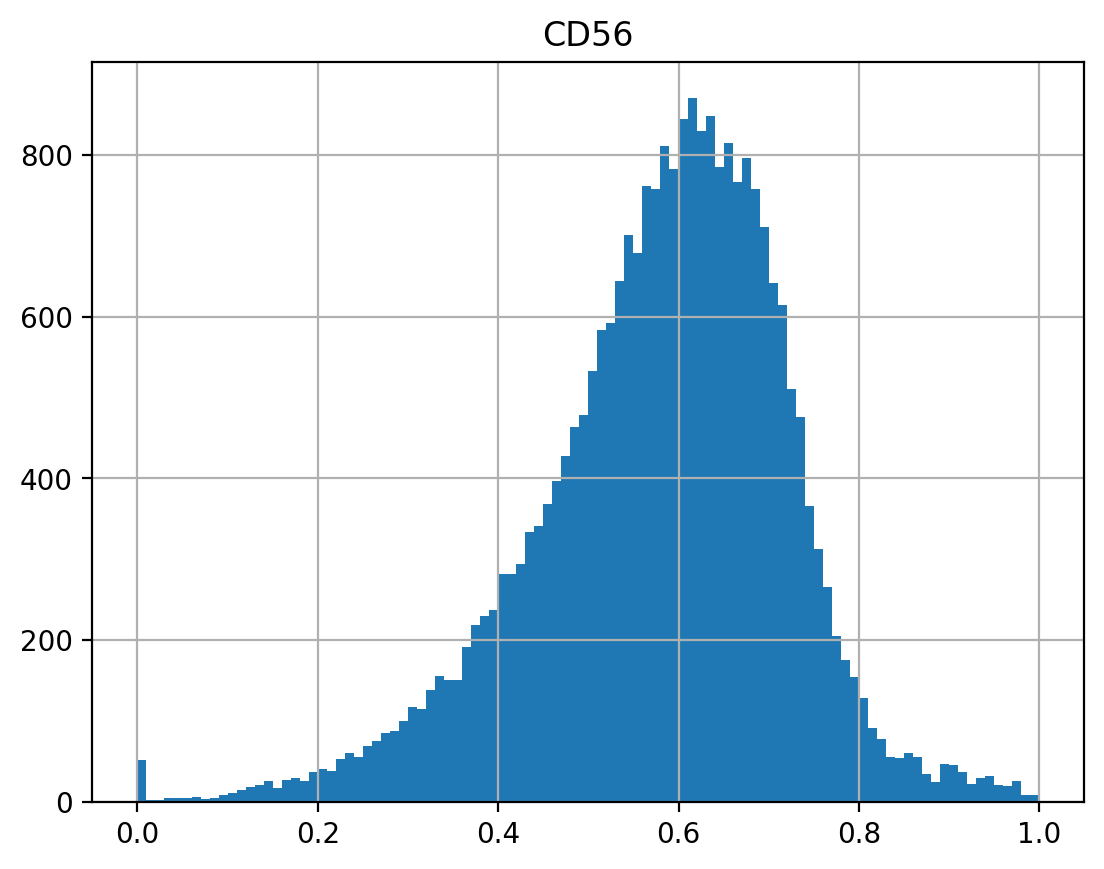

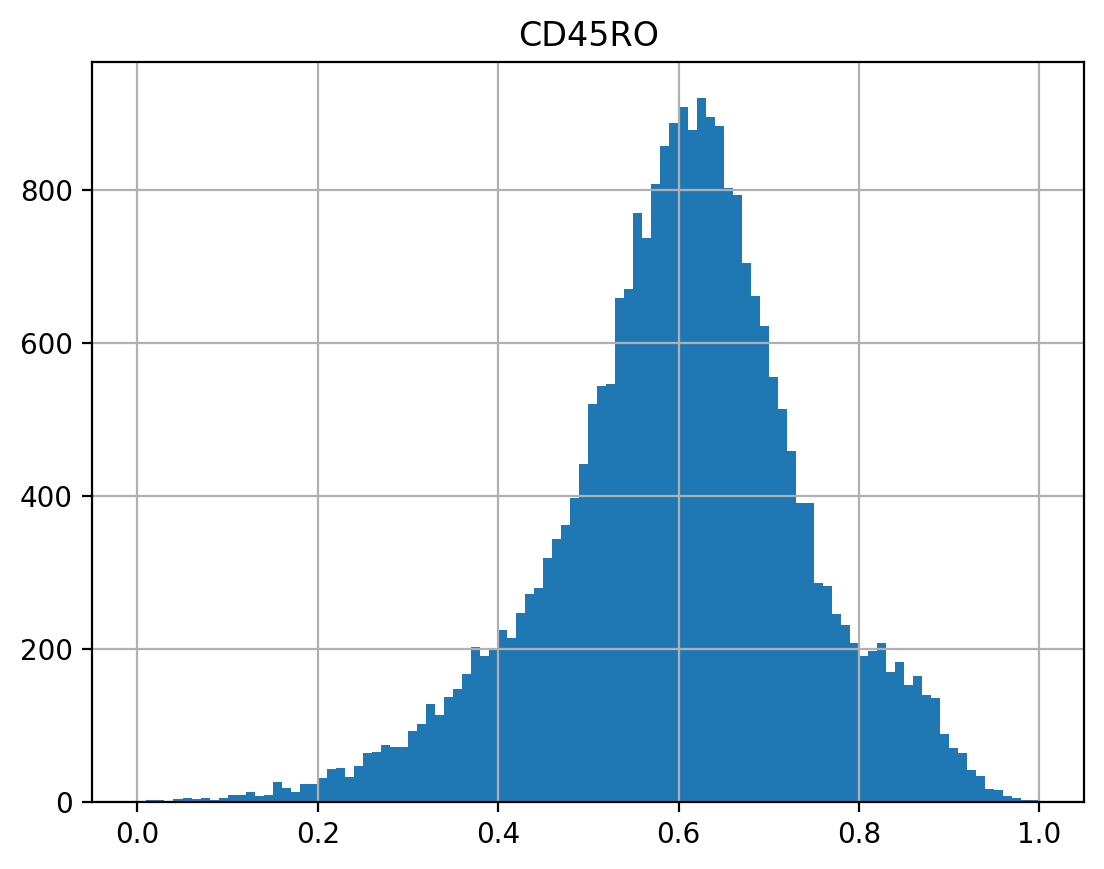

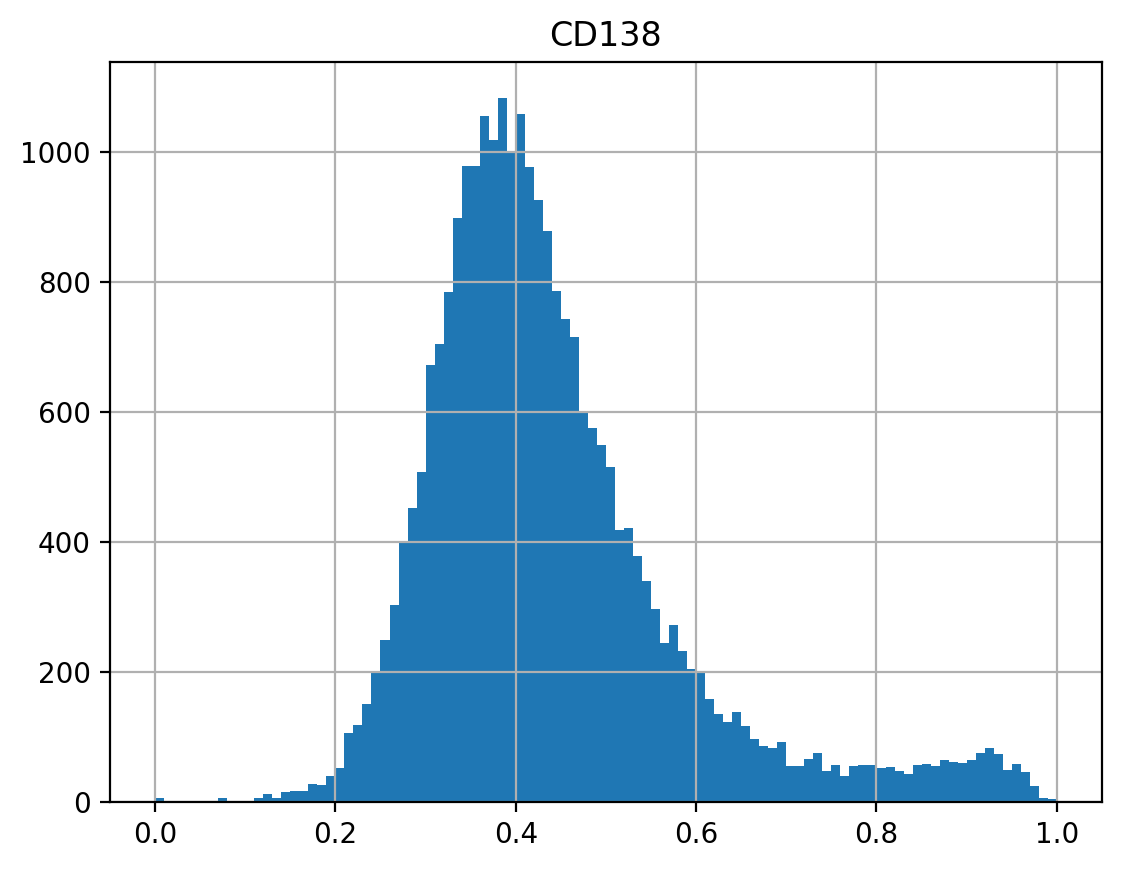

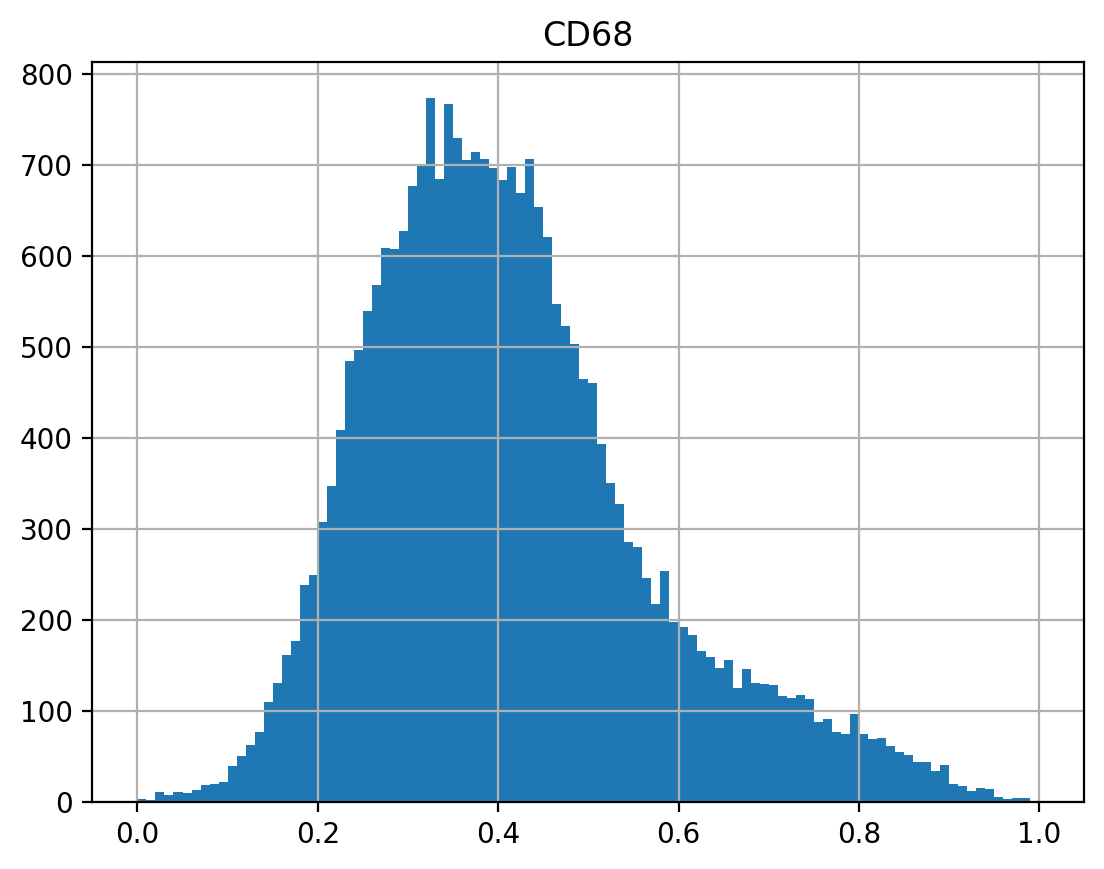

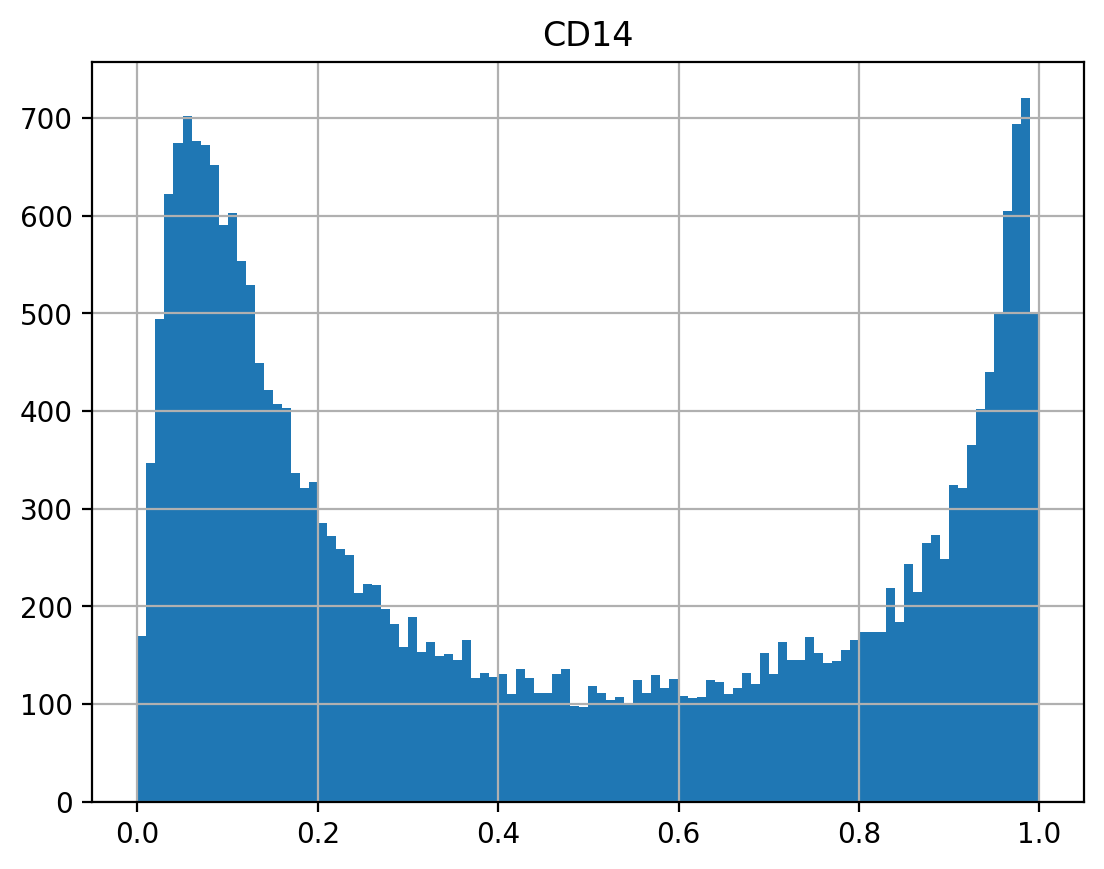

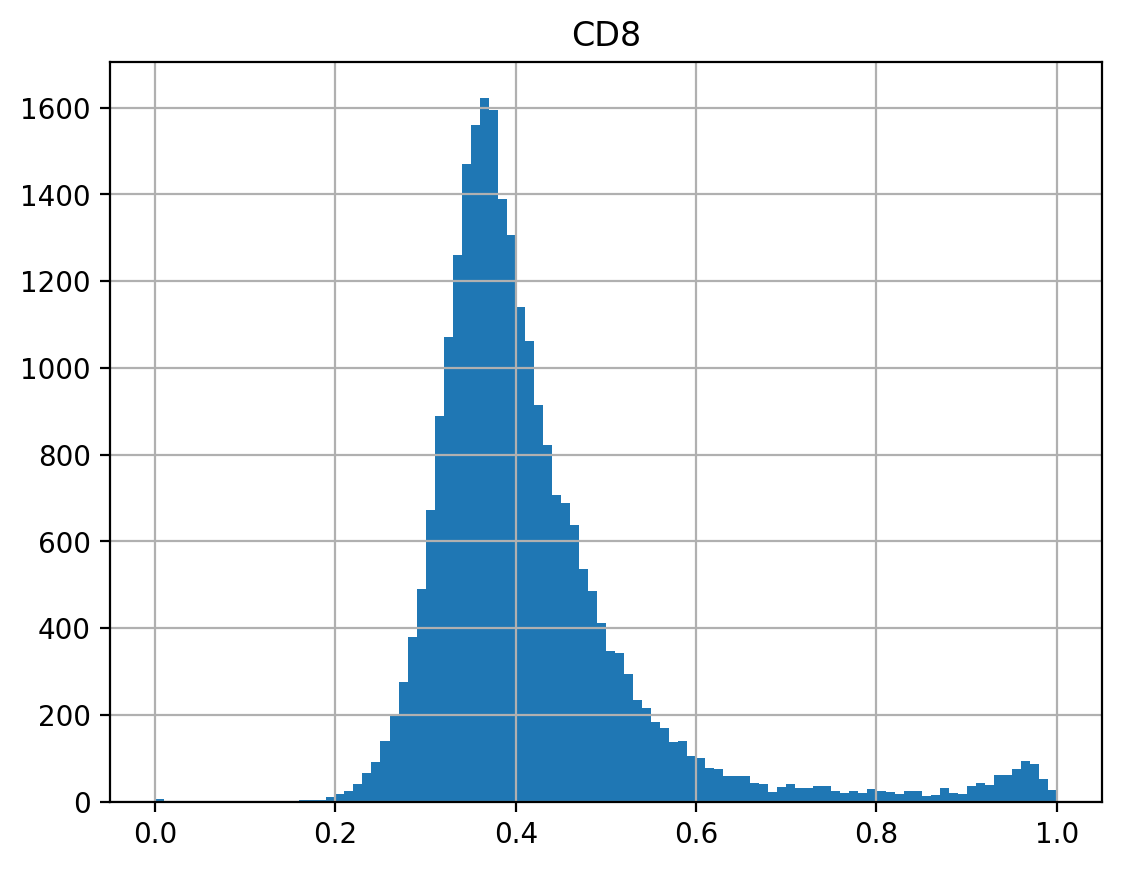

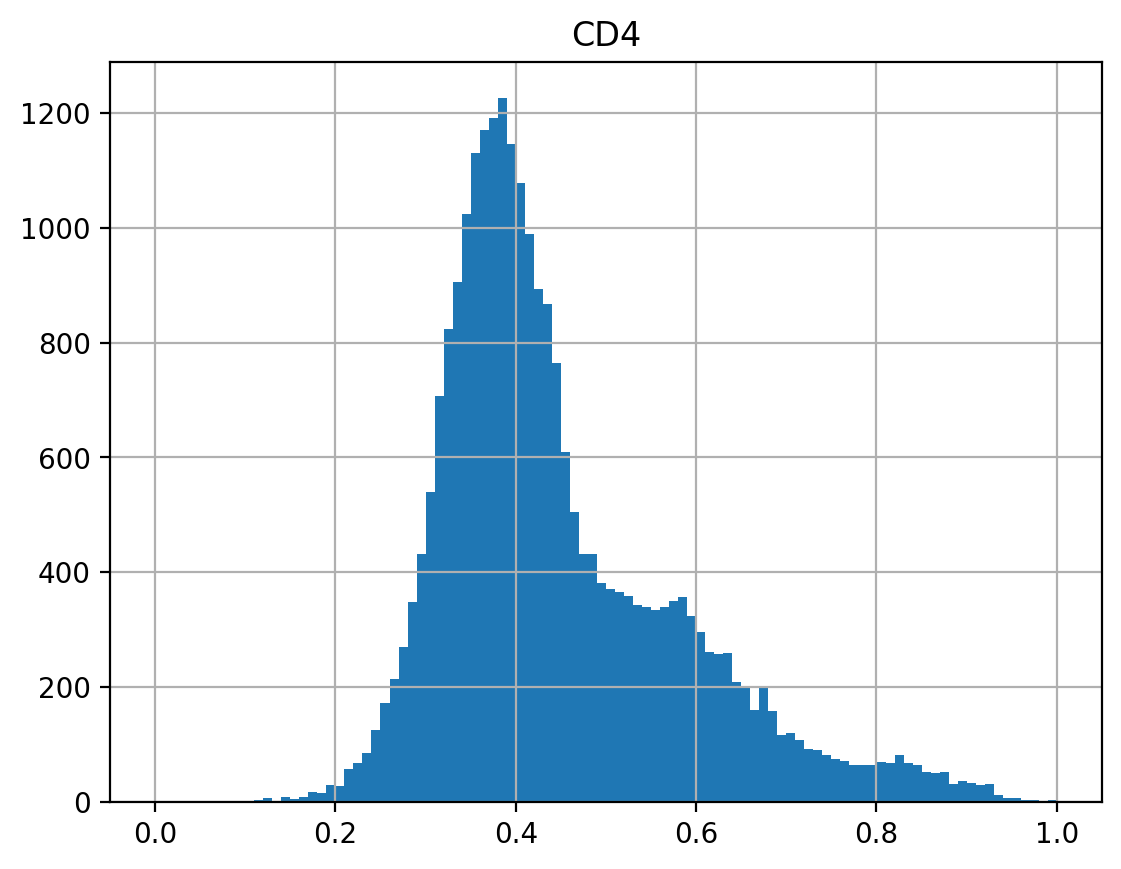

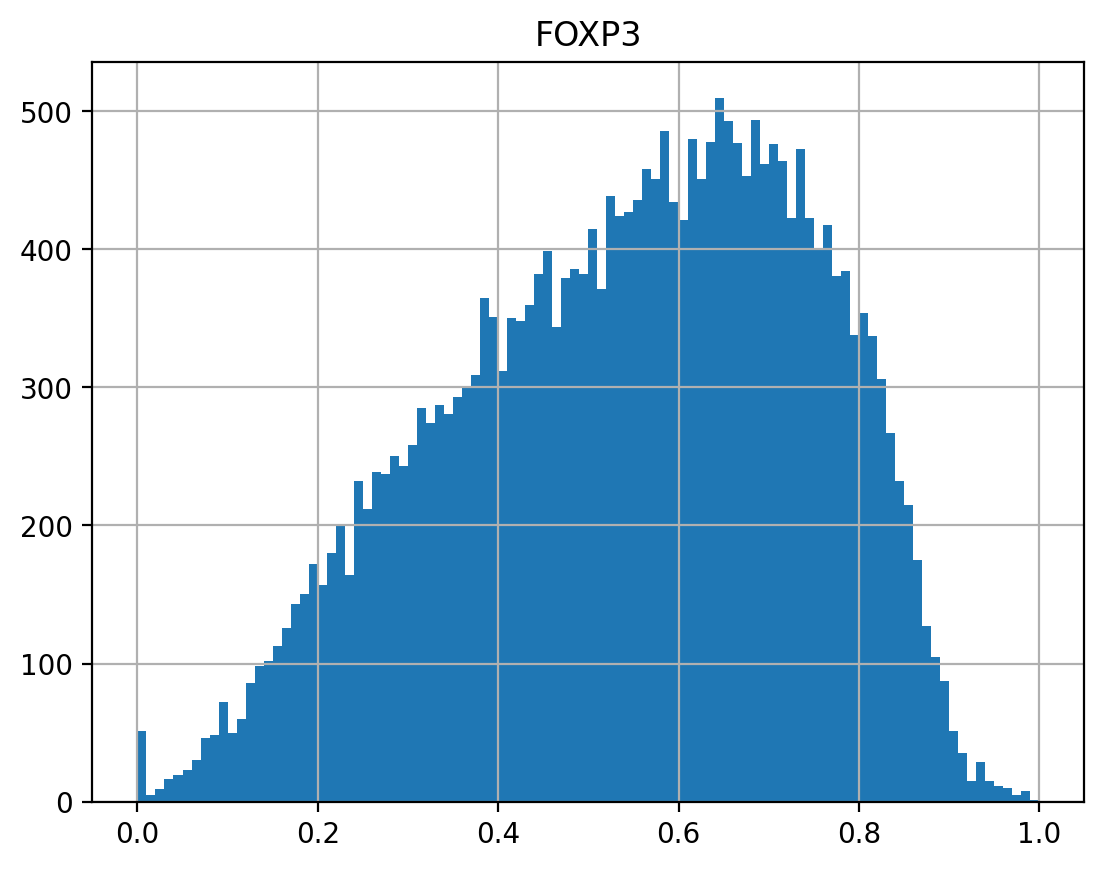

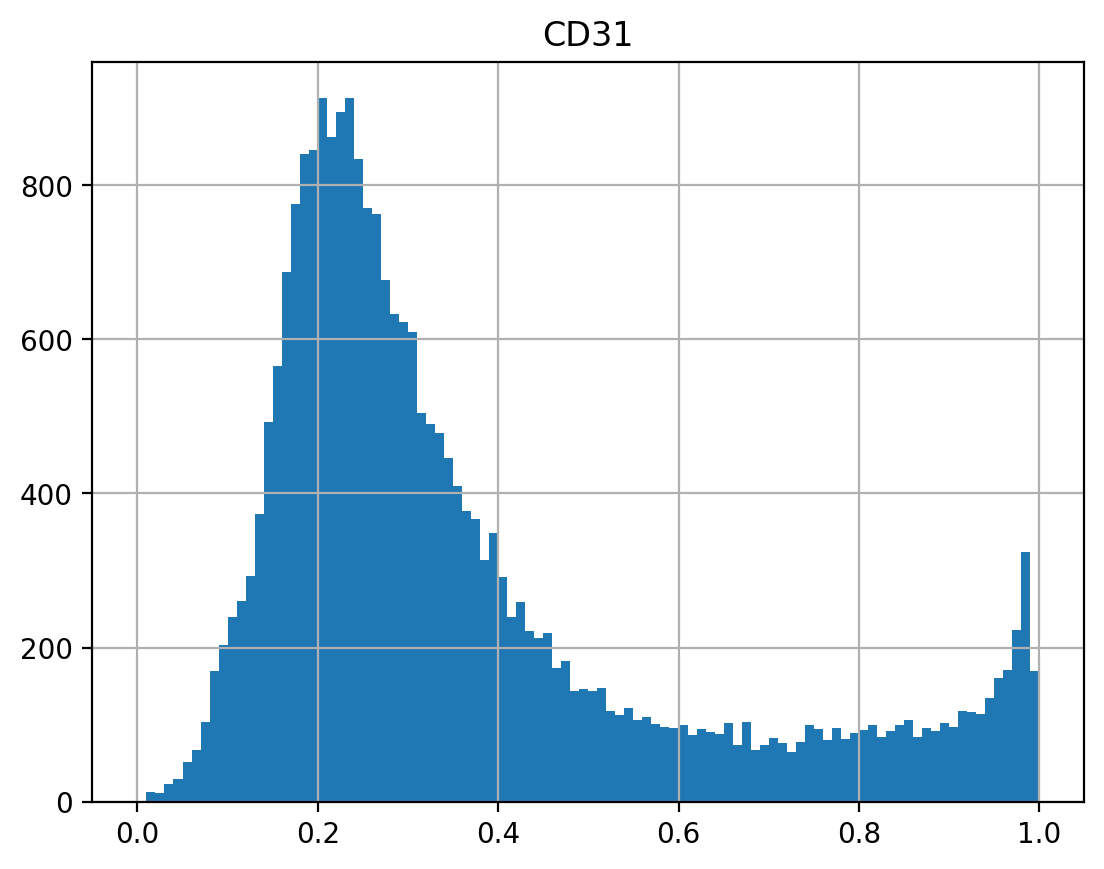

In [35]:
for marker in celesta_pmap.columns[1::]:
    celesta_pmap.hist(column=marker,bins=100)

## 2.2 Kmeans 

In [36]:
def cluster(img, K=3):
    
    aux=np.float32(img.flatten())
    criteria=(cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER,10,1.0)
    ret,label,center=cv.kmeans(aux,K,None,criteria,3, cv.KMEANS_PP_CENTERS )#cv.KMEANS_RANDOM_CENTERS)
    og_center=np.copy(center)
    low=np.argmin(center)
    hi=np.argmax(center)
    mid=np.setdiff1d([0,1,2],[low,hi])[0]
    center[low]=1
    center[mid]=2
    center[hi]=3
    clustered=(center[label.flatten()]).reshape(img.shape)
    
    return clustered,og_center

In [37]:
expression_map={}
for marker in celesta_pmap.columns[1::]:
    cluster_labels,cent=cluster(celesta_pmap[marker].values)
    expression_map[marker+'_exp_level']=cluster_labels
df_expression=pd.DataFrame(expression_map,index=celesta_pmap.index.values)

expression_map_cluster=pd.concat([celesta_pmap,df_expression],axis=1)
expression_map_cluster.to_csv(data_dir / 'celesta_pmap_exp_level_clusters.csv',index=False)
expression_map_cluster

,cell_label,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,...,CD20_exp_level,CD56_exp_level,CD45RO_exp_level,CD138_exp_level,CD68_exp_level,CD14_exp_level,CD8_exp_level,CD4_exp_level,FOXP3_exp_level,CD31_exp_level
0,1,0.365390,0.030263,0.227827,0.338736,0.778946,0.270397,0.196068,0.393930,0.653326,...,1.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0
1,2,0.155278,0.352776,0.495362,0.350731,0.848248,0.300029,0.180489,0.312740,0.517845,...,1.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0
2,3,0.694887,0.125403,0.301102,0.365518,0.532395,0.345496,0.293001,0.169489,0.675915,...,1.0,1.0,3.0,1.0,2.0,3.0,2.0,3.0,2.0,1.0
3,4,0.083916,0.386513,0.108594,0.334409,0.564205,0.769635,0.505292,0.189973,0.584317,...,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,5,0.119430,0.426636,0.547941,0.450508,0.333117,0.407027,0.342674,0.282912,0.562413,...,2.0,1.0,2.0,1.0,3.0,1.0,3.0,2.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25800,25801,0.411455,0.613424,0.396641,0.292556,0.000000,0.431159,0.838558,0.484147,0.597942,...,3.0,2.0,2.0,1.0,3.0,3.0,2.0,1.0,2.0,3.0
25801,25802,0.313515,0.828356,0.499769,0.276807,0.000000,0.480021,0.853470,0.559759,0.327599,...,3.0,2.0,1.0,1.0,3.0,3.0,2.0,2.0,2.0,3.0
25802,25803,0.411371,0.658798,0.434870,0.229602,0.000000,0.447377,0.853860,0.222027,0.340634,...,3.0,1.0,1.0,1.0,3.0,3.0,2.0,2.0,2.0,3.0
25803,25804,0.529551,0.564943,0.931018,0.183066,0.000000,0.424941,0.831923,0.792515,0.377531,...,3.0,3.0,1.0,2.0,3.0,3.0,1.0,3.0,3.0,3.0


In [38]:
thr_kmeans={}

for marker in celesta_pmap.columns[1::]:
    
    threshold_hi=expression_map_cluster.loc[expression_map_cluster[marker+'_exp_level']==3][marker].values.min()
    threshold_mi=expression_map_cluster.loc[expression_map_cluster[marker+'_exp_level']==2][marker].values.max()
    threshold_lo=expression_map_cluster.loc[expression_map_cluster[marker+'_exp_level']==1][marker].values.max()
    
    thr_kmeans[marker]=[f'{threshold_hi:.2f}',f'{threshold_mi:.2f}',f'{threshold_lo:.2f}']
    
thr_kmeans_df=pd.DataFrame(thr_kmeans,index=['hi_bottom','mid_celing','lo_ceiling'])
thr_kmeans_df.to_csv(data_dir / 'round_{s}'.format(s=round_suffix)   / 'celesta_output' / 'kmeans' / 'thr_input.csv')

thr_kmeans_df

,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
hi_bottom,0.72,0.64,0.68,0.60,0.70,0.49,0.53,0.65,0.65,0.63,0.53,0.69,0.71,0.55,0.65,0.64
mid_celing,0.72,0.64,0.68,0.60,0.70,0.49,0.53,0.65,0.65,0.63,0.53,0.69,0.71,0.55,0.65,0.64
lo_ceiling,0.43,0.26,0.37,0.38,0.40,0.28,0.30,0.42,0.47,0.43,0.32,0.31,0.41,0.41,0.35,0.34


In [18]:
thr_otsu_df

NameError: name 'thr_otsu_df' is not defined

In [126]:
ann_pmap_min_df

,CD3,CD66b,Cytokeratin,Mast_Cell_Tryptase,Actin,Myosin_Smooth_Muscle,CD20,CD56,CD45RO,CD138,CD68,CD14,CD8,CD4,FOXP3,CD31
0,0.85,0.97,0.78,0.90,0.21,0.57,0.89,0.83,0.26,0.83,0.19,0.01,0.00,0.29,0.00,0.96


# Create ampel_masks for each marker

In [127]:
macsiq_labels=df_macsiq_filt['cell_id'].values#labels of interest
filtered_map=expression_map_cluster[expression_map_cluster['cell_label'].isin(macsiq_labels)]

for marker in markers_list:
    for exp_level in [1,2,3]:
        exp_canvas=np.zeros(seg_masks.shape,dtype='uint8')
        aux_labels=filtered_map.loc[filtered_map[marker+'_exp_level']==exp_level].cell_label.values
        exp_canvas[np.isin(seg_masks,aux_labels)]=255
        output_folder=data_dir / 'round_{s}'.format(s=round_suffix)  / 'expression_clusters_masks' / marker
        Path(output_folder ).mkdir(parents=True, exist_ok=True)
        tifff.imwrite(output_folder / '{M}_exp_level_{e}.tif'.format(M=marker,e=f'{exp_level:02d}'),exp_canvas)